In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import statsmodels as stat
import datetime as dt
import matplotlib.dates as mdates
import os
import folium
import json
import matplotlib.dates as mdates
from matplotlib.cbook import boxplot_stats
from pprint import pprint
from glob import glob
from IPython.display import display, Image, IFrame
from matplotlib.ticker import FormatStrFormatter, FuncFormatter
import missingno as msno
from matplotlib.ticker import FormatStrFormatter, FuncFormatter
# Plotly Libraries
import plotly.express as px
import plotly.graph_objects as go
import plotly
# initialize plotly for jupyter notebook
plotly.offline.init_notebook_mode()
from scipy.stats import chi2_contingency
from scipy.stats import chi2

In [2]:
# Extraction des données de base des données sqlite3

In [3]:
import sqlite3
import pandas as pd

# Connexion à la base de données SQLite
connexion = sqlite3.connect('olist (8).db')
curseur = connexion.cursor()

try:
    # Obtenez la liste de toutes les tables
    curseur.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = curseur.fetchall()
    print("Tables dans la base de données:", tables)

    # Charger chaque table dans une variable globale
    for table_name_tuple in tables:
        table_name = table_name_tuple[0]
        globals()[table_name] = pd.read_sql_query(f"SELECT * FROM {table_name}", connexion)
        print(f"Contenu de la table {table_name} chargé dans la variable globale du même nom.")

    # Exemple d'utilisation d'une table chargée globalement (ajuster le nom de table selon vos données)
   # if 'customers' in globals():
        print(customers.head())
   # else:
        #print("La table 'customers' n'existe pas dans la base de données.")

finally:
    # Fermeture du curseur et de la connexion à la base de données
    curseur.close()
    connexion.close()

Tables dans la base de données: [('customers',), ('geoloc',), ('order_items',), ('order_pymts',), ('order_reviews',), ('orders',), ('products',), ('sellers',), ('translation',)]
Contenu de la table customers chargé dans la variable globale du même nom.
   index                       customer_id                customer_unique_id  \
0      0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1      1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2      2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3      3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4      4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo            

In [4]:
customers.head()

,index,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [5]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   index                          99441 non-null  int64 
 1   order_id                       99441 non-null  object
 2   customer_id                    99441 non-null  object
 3   order_status                   99441 non-null  object
 4   order_purchase_timestamp       99441 non-null  object
 5   order_approved_at              99281 non-null  object
 6   order_delivered_carrier_date   97658 non-null  object
 7   order_delivered_customer_date  96476 non-null  object
 8   order_estimated_delivery_date  99441 non-null  object
dtypes: int64(1), object(8)
memory usage: 6.8+ MB


In [6]:
# Autres manière de telecharger les tables de Kaggle

In [7]:
#chargement des données 
orders = pd.read_csv("olist_orders_dataset.csv")

order_item = pd.read_csv("olist_order_items_dataset.csv")

order_review = pd.read_csv("olist_order_reviews_dataset.csv")

products = pd.read_csv("olist_products_dataset.csv")

payments = pd.read_csv("olist_order_payments_dataset.csv")

customer = pd.read_csv("olist_customers_dataset.csv")

sellers = pd.read_csv("olist_sellers_dataset.csv")

geolocation = pd.read_csv("olist_geolocation_dataset.csv")

category_name = pd.read_csv("product_category_name_translation.csv")

In [8]:
def description_dataset(data, matrix):
    '''
    Return the description of a dataset
    
        Parameters: 
            data: dataframe
            matrix(bool): indicates if we plot the msno matrix of data
            
        Returns:
            the 3 first line of the dataframe
            the shape, the types, th number of null values,
            the number of unique values, the number of duplicated values
            
    '''
    if matrix == True:
        msno.matrix(data)
        
    display(data.head(3))
    print(f'Taille :-------------------------------------------------------------- {data.shape}')
    print("--"*50)
    print(f'Types :{data.dtypes.value_counts()}')
    print("--"*50)
    print(f'Types :{data.dtypes}')
    print("--"*50)
    print("Valeurs manquantes par colonnes (%): ")
    print((((data.isna().sum()/data.shape[0])*100).round(2)).sort_values(ascending= False))
    print("--"*50)
    print("Valeurs différentes par variables : ")
    for col in data:
        if data[col].nunique() < 30:
            print (f'{col :-<70} {data[col].unique()}')
        else : 
            print(f'{col :-<70} contient {data[col].nunique()} valeurs différentes')
    print("--"*50)
    print(f"Nombre de doublons : {data.duplicated().sum()}")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


Taille :-------------------------------------------------------------- (99441, 8)
----------------------------------------------------------------------------------------------------
Types :object    8
dtype: int64
----------------------------------------------------------------------------------------------------
Types :order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object
----------------------------------------------------------------------------------------------------
Valeurs manquantes par colonnes (%): 
order_delivered_customer_date    2.98
order_delivered_carrier_date     1.79
order_approved_at                0.16
order_id                         0.00
customer_id                      0.00
order_status  

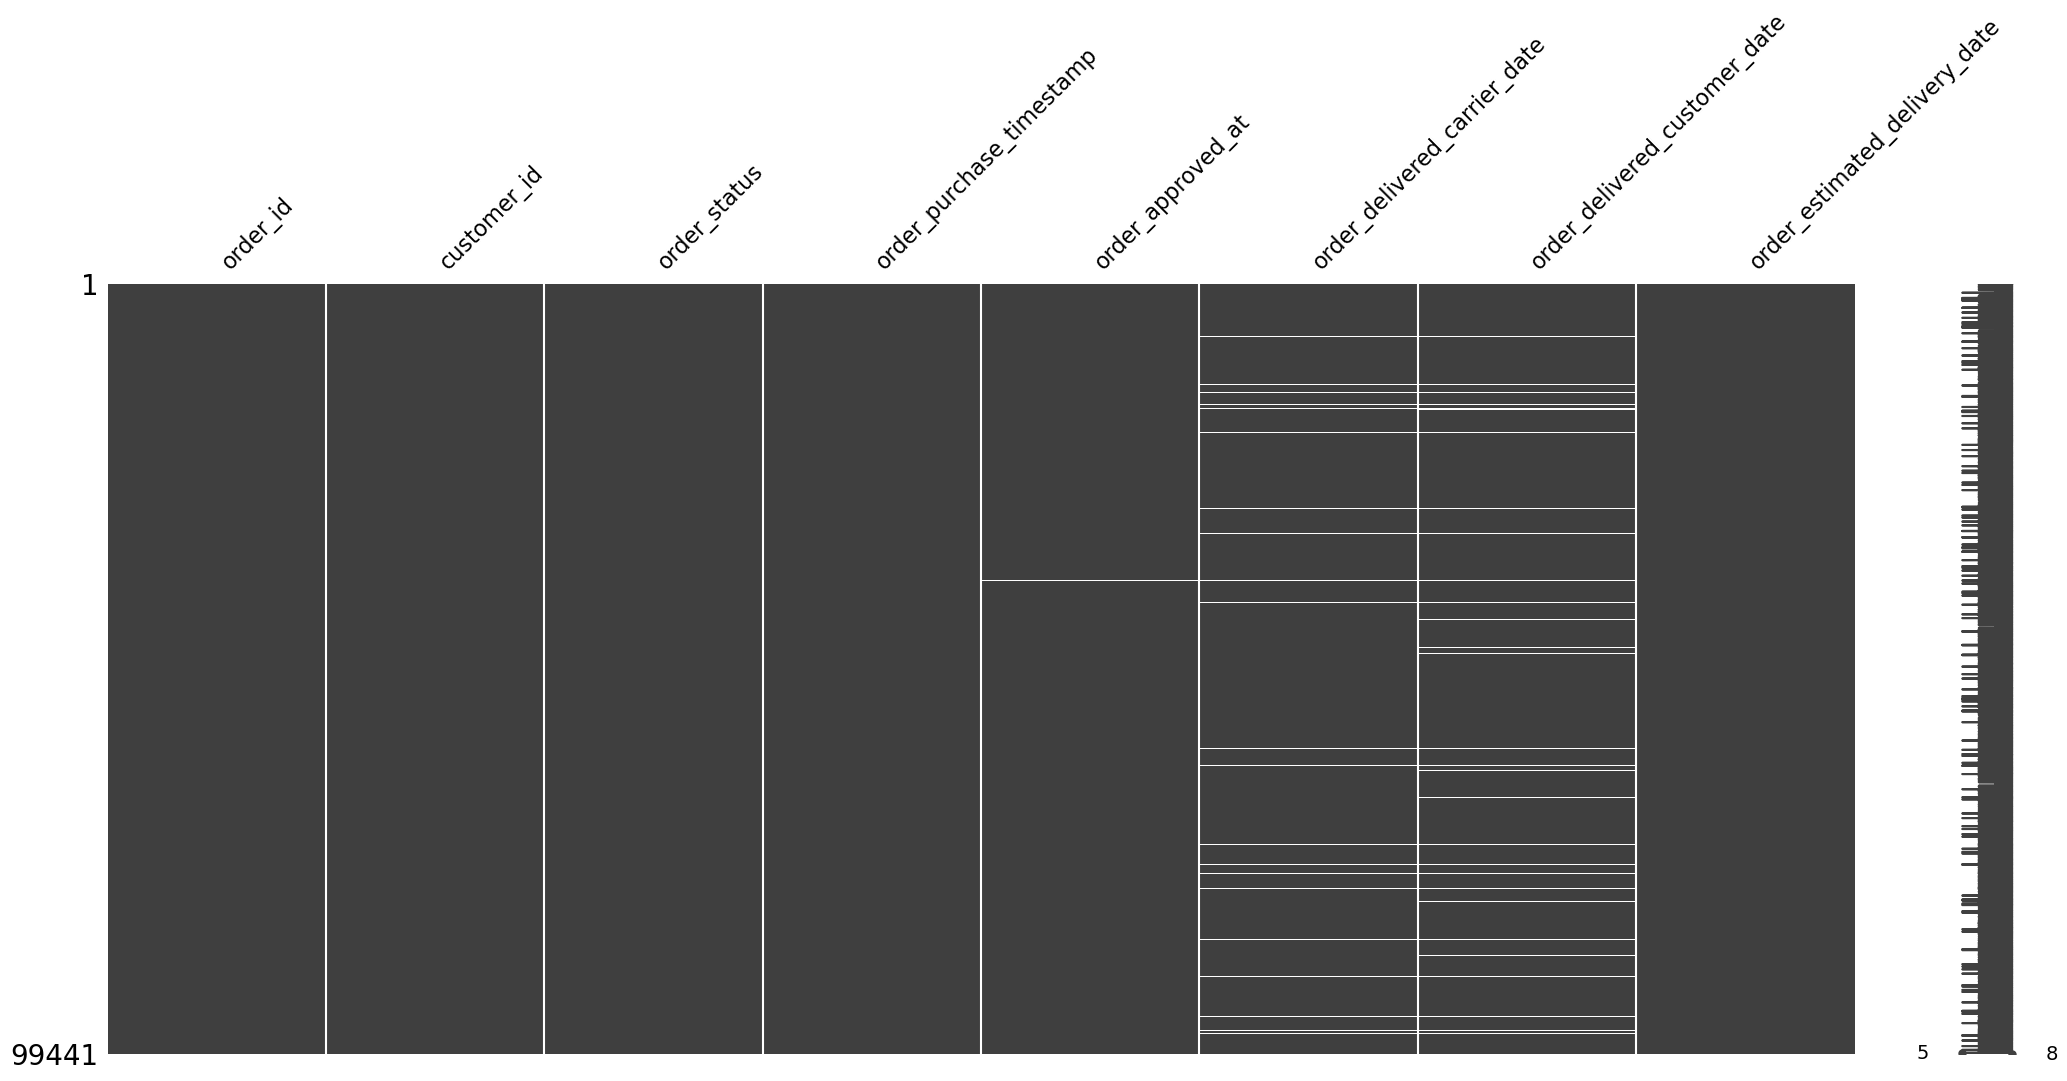

In [9]:
description_dataset(orders, matrix = True)

In [10]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [11]:
orders['order_status'].sort_values().value_counts()

delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: order_status, dtype: int64

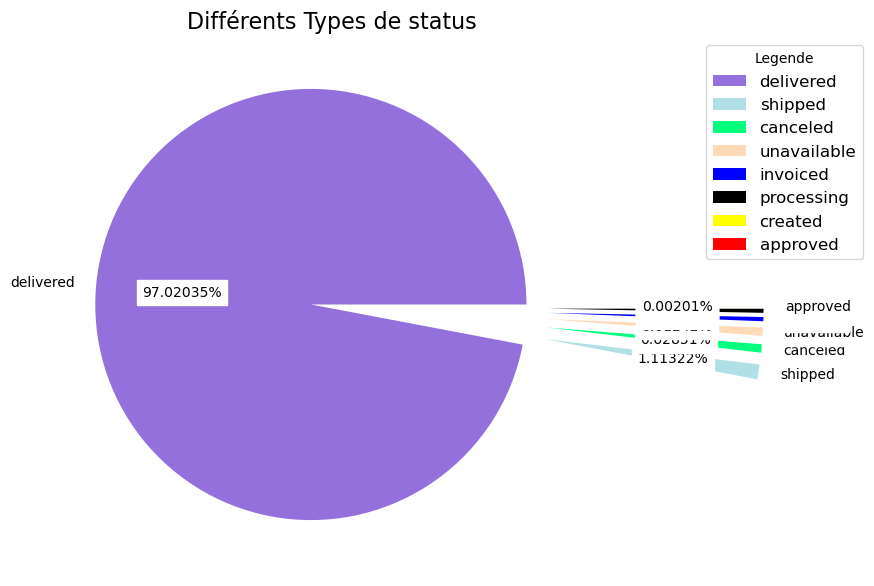

In [12]:
plt.figure(figsize=(10, 7))
list_colors = ['MediumPurple', 'PowderBlue', 'SpringGreen', 'PeachPuff', 'Blue', 'Black', 'Yellow', 'Red']   
plt.title('Différents Types de status', size=16)
nb_par_var = orders['order_status'].sort_values().value_counts()

# Calcul de la longueur de la liste explode
num_categories = len(nb_par_var)

# Génération de la liste explode
explode = [0.1] + [1] * (num_categories - 1)

# Tracé du diagramme en secteurs
wedges, texts, autotexts = plt.pie(
    nb_par_var, labels=nb_par_var.index, autopct='%1.5f%%', colors=list_colors, 
    textprops={'fontsize': 10, 'color': 'black', 'backgroundcolor': 'w'}, explode=explode)

# Légende
plt.legend(wedges, nb_par_var.index, title='Legende', loc='upper right', fontsize=12, bbox_to_anchor=(1, 0, 0.5, 1))

plt.show()

In [14]:
date_cols = ['order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date']


orders[date_cols] = orders[date_cols].apply(pd.to_datetime)

In [15]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [16]:
# Période de commande (dernier achat)?
min = orders['order_purchase_timestamp'].min().strftime('%d/%m/%Y %Hh%m')
max = orders['order_purchase_timestamp'].max().strftime('%d/%m/%Y %Hh%m')
print(f'Période d\'achat : du {min} au {max}')

Période d'achat : du 04/09/2016 21h09 au 17/10/2018 17h10


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


Taille :-------------------------------------------------------------- (112650, 7)
----------------------------------------------------------------------------------------------------
Types :object     4
float64    2
int64      1
dtype: int64
----------------------------------------------------------------------------------------------------
Types :order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object
----------------------------------------------------------------------------------------------------
Valeurs manquantes par colonnes (%): 
order_id               0.0
order_item_id          0.0
product_id             0.0
seller_id              0.0
shipping_limit_date    0.0
price                  0.0
freight_value          0.0
dtype: float64
---------------------------------------------------------------------------

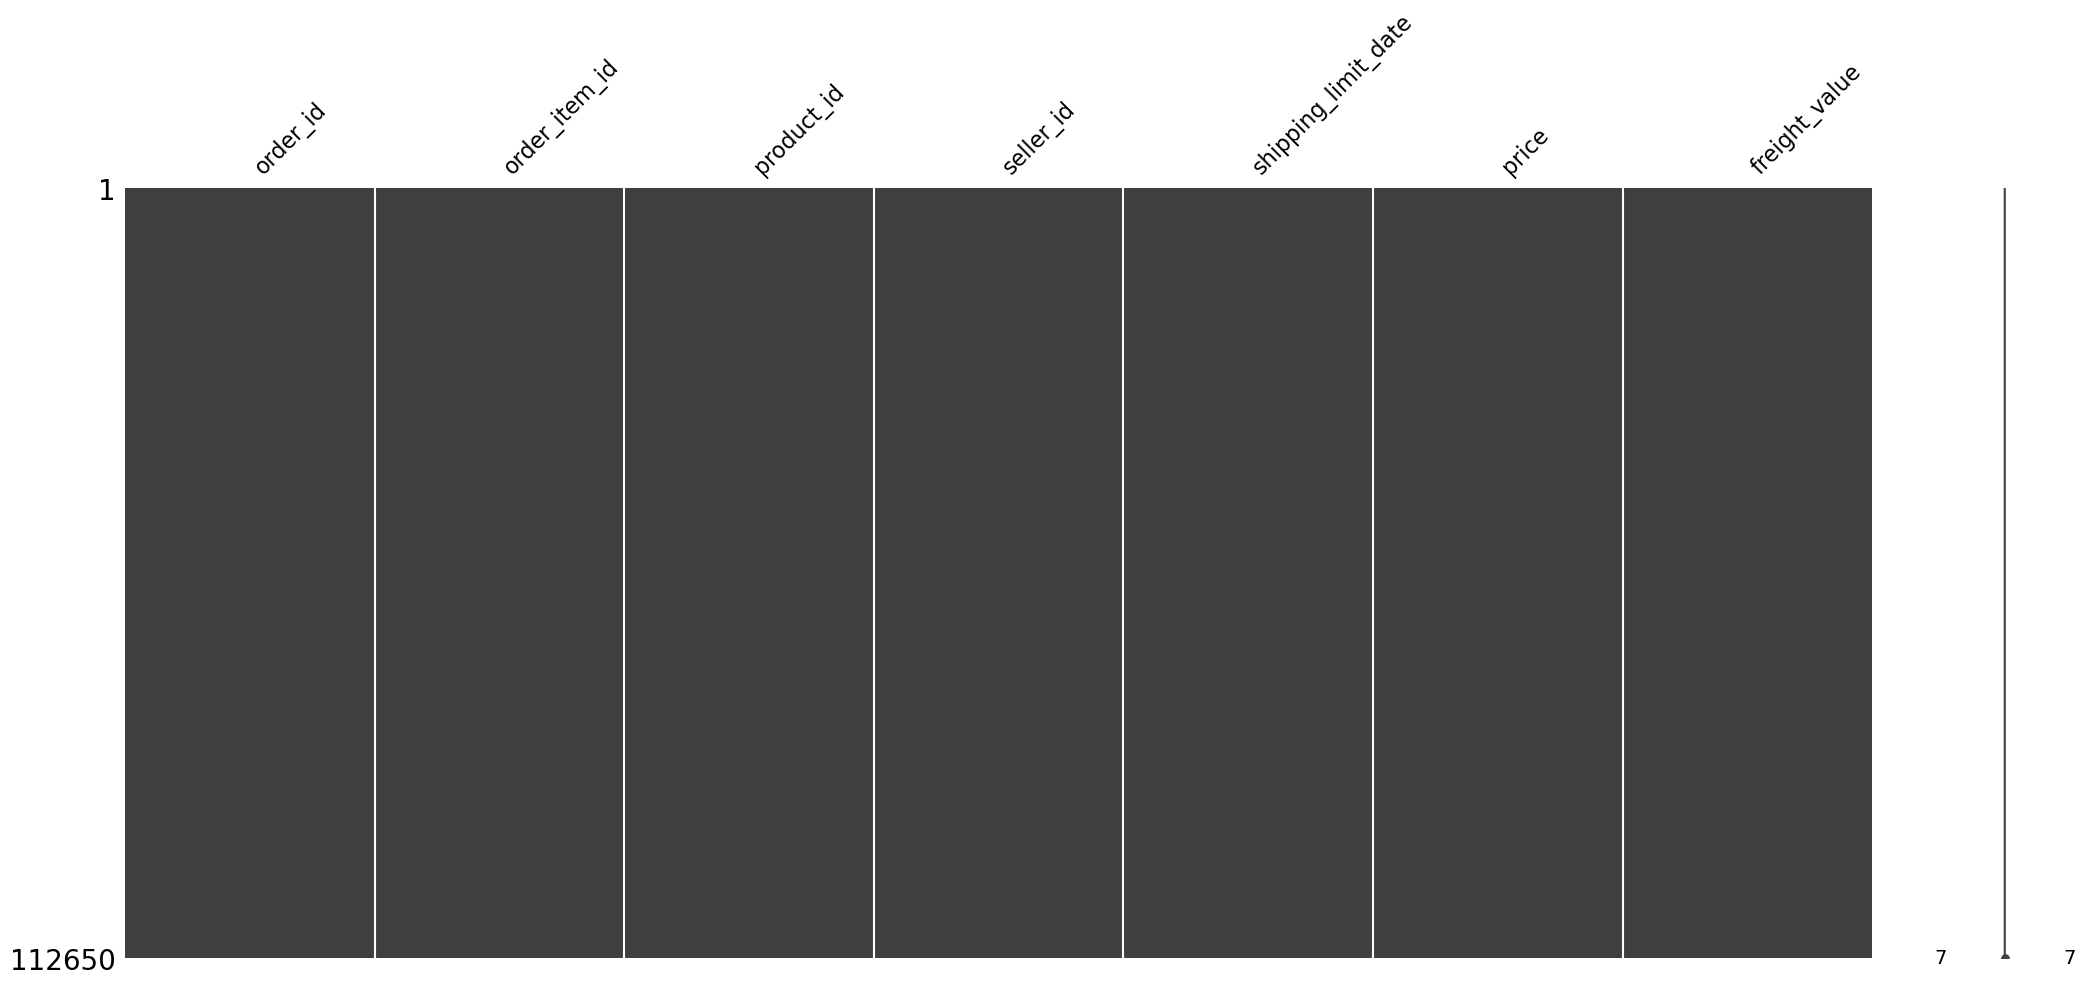

In [17]:

description_dataset(order_item, matrix=True)

In [18]:
order_item.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [19]:
order_item['product_id'].value_counts()

aca2eb7d00ea1a7b8ebd4e68314663af    527
99a4788cb24856965c36a24e339b6058    488
422879e10f46682990de24d770e7f83d    484
389d119b48cf3043d311335e499d9c6b    392
368c6c730842d78016ad823897a372db    388
                                   ... 
dbc42f8ad8afd0147a5a46be630781f8      1
5d86ed92606c80a89e547cdba3946812      1
0b8750fa58fefe42cf03a9e2e4b8fce6      1
a4758e74e2cdb74d0c4db83594ca14a3      1
350688d9dc1e75ff97be326363655e01      1
Name: product_id, Length: 32951, dtype: int64

In [20]:
order_item['product_id'].value_counts()

aca2eb7d00ea1a7b8ebd4e68314663af    527
99a4788cb24856965c36a24e339b6058    488
422879e10f46682990de24d770e7f83d    484
389d119b48cf3043d311335e499d9c6b    392
368c6c730842d78016ad823897a372db    388
                                   ... 
dbc42f8ad8afd0147a5a46be630781f8      1
5d86ed92606c80a89e547cdba3946812      1
0b8750fa58fefe42cf03a9e2e4b8fce6      1
a4758e74e2cdb74d0c4db83594ca14a3      1
350688d9dc1e75ff97be326363655e01      1
Name: product_id, Length: 32951, dtype: int64

In [21]:
#filtred_counts = order_item['product_id'].value_counts()[order_item['product_id'].value_counts() >= 100]

# Tracer le graphique
#plt.barh(filtred_counts.index, filtred_counts.values)
#plt.xlabel('Nombre de occurrences')
#plt.ylabel('product_id')
#plt.title('Occurrences de product_id avec une fréquence >= 100')
#plt.show()

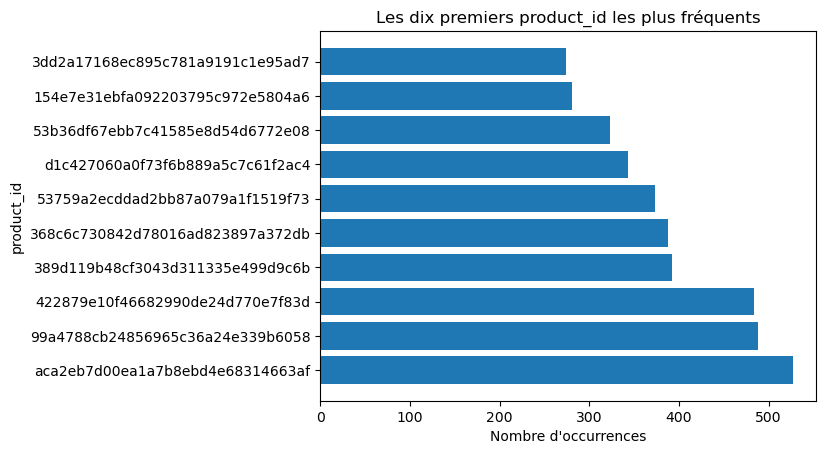

In [22]:
top_10_product_ids = order_item['product_id'].value_counts().head(10)

# Tracer le graphique
plt.barh(top_10_product_ids.index, top_10_product_ids.values)
plt.xlabel('Nombre d\'occurrences')
plt.ylabel('product_id')
plt.title('Les dix premiers product_id les plus fréquents')
plt.show()

In [23]:
order_item['order_id'].nunique()

98666

In [24]:
order_item['seller_id'].nunique()

3095

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0


Taille :-------------------------------------------------------------- (32951, 9)
----------------------------------------------------------------------------------------------------
Types :float64    7
object     2
dtype: int64
----------------------------------------------------------------------------------------------------
Types :product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float64
dtype: object
----------------------------------------------------------------------------------------------------
Valeurs manquantes par colonnes (%): 
product_category_name         1.85
product_name_lenght           1.85
product_description_lenght    1.85
product_photos_qty            1.85
product_weight_g            

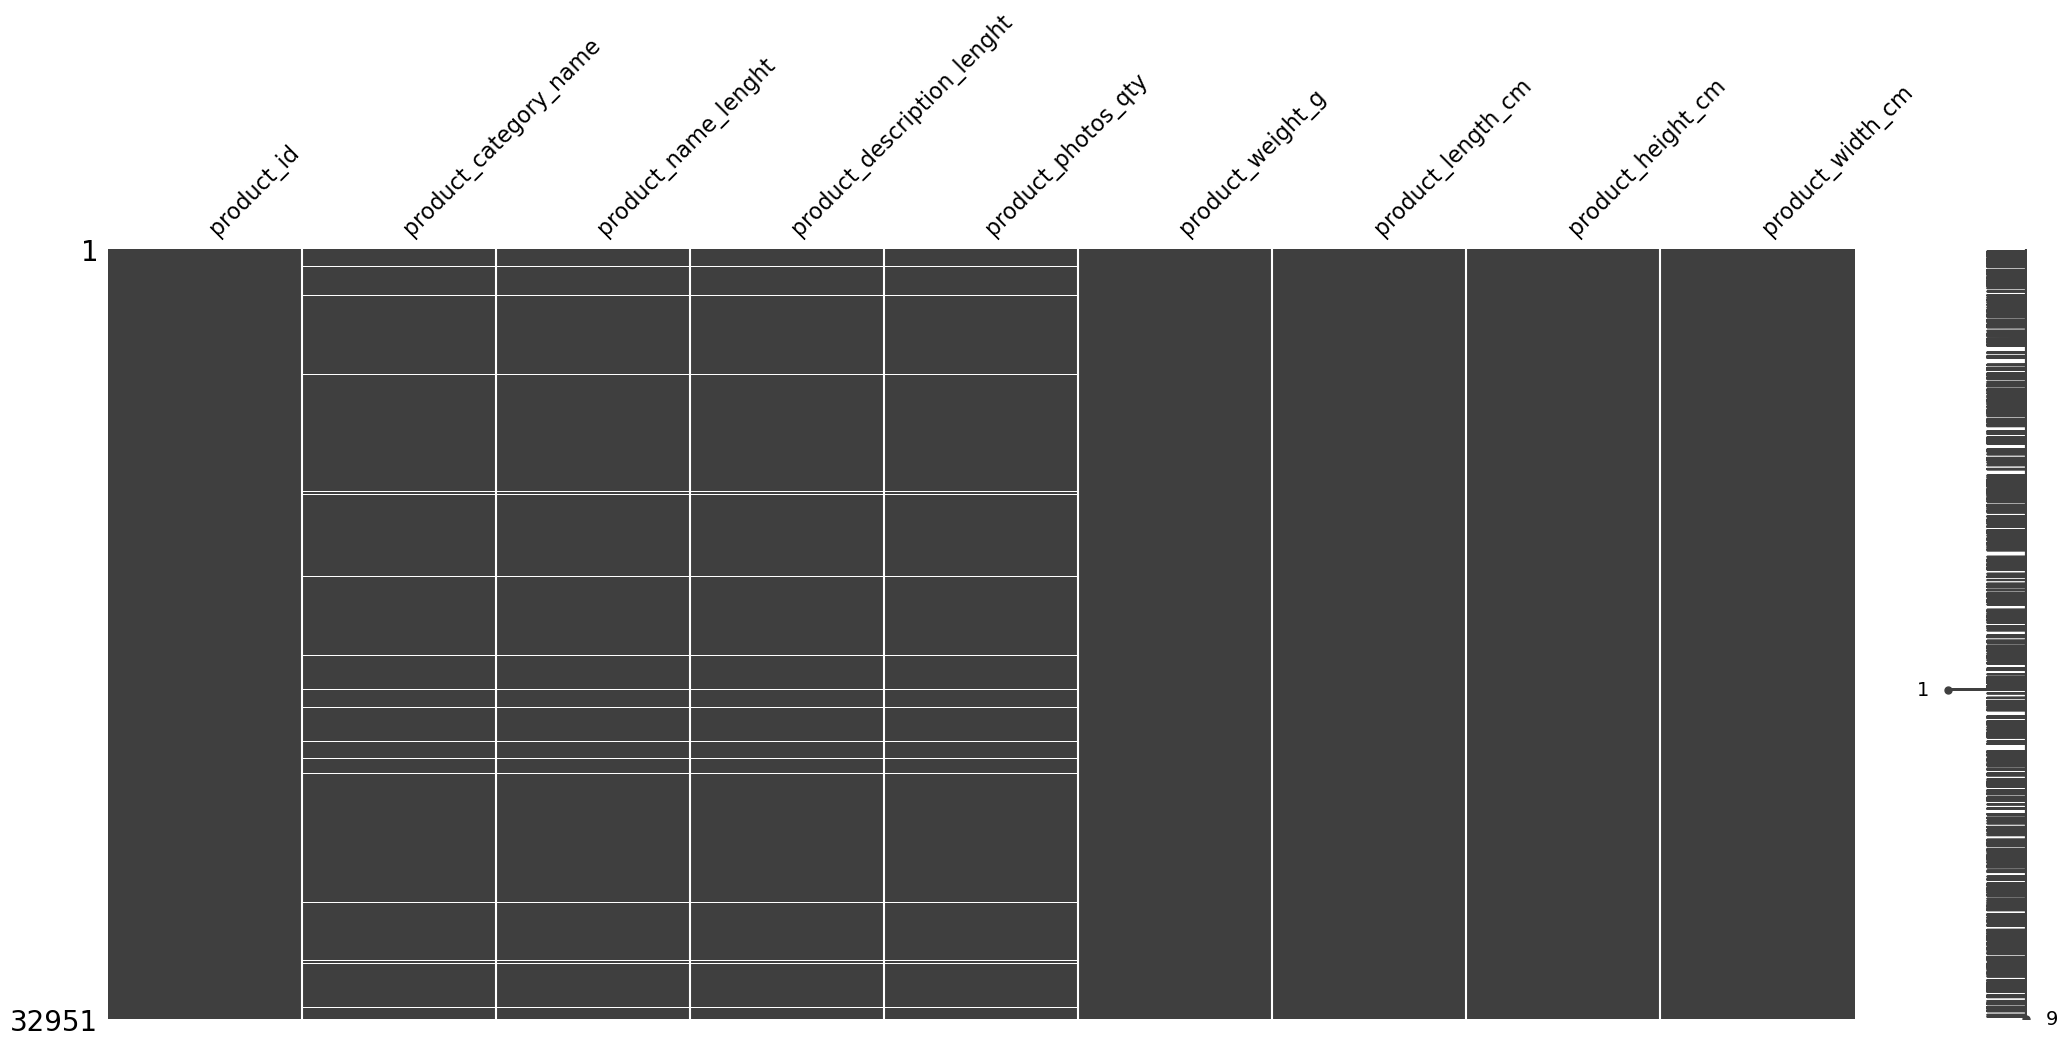

In [25]:
description_dataset(products,matrix = True)

In [26]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [27]:
print((((products.isna().sum()/products.shape[0])*100).round(2)).sort_values(ascending= False))

product_category_name         1.85
product_name_lenght           1.85
product_description_lenght    1.85
product_photos_qty            1.85
product_weight_g              0.01
product_length_cm             0.01
product_height_cm             0.01
product_width_cm              0.01
product_id                    0.00
dtype: float64


In [28]:
products.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [29]:
products['product_category_name'].value_counts()

cama_mesa_banho                  3029
esporte_lazer                    2867
moveis_decoracao                 2657
beleza_saude                     2444
utilidades_domesticas            2335
                                 ... 
fashion_roupa_infanto_juvenil       5
casa_conforto_2                     5
pc_gamer                            3
seguros_e_servicos                  2
cds_dvds_musicais                   1
Name: product_category_name, Length: 73, dtype: int64

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71


Taille :-------------------------------------------------------------- (103886, 5)
----------------------------------------------------------------------------------------------------
Types :object     2
int64      2
float64    1
dtype: int64
----------------------------------------------------------------------------------------------------
Types :order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object
----------------------------------------------------------------------------------------------------
Valeurs manquantes par colonnes (%): 
order_id                0.0
payment_sequential      0.0
payment_type            0.0
payment_installments    0.0
payment_value           0.0
dtype: float64
----------------------------------------------------------------------------------------------------
Valeurs différentes par variables : 
order_id-----------------------------------

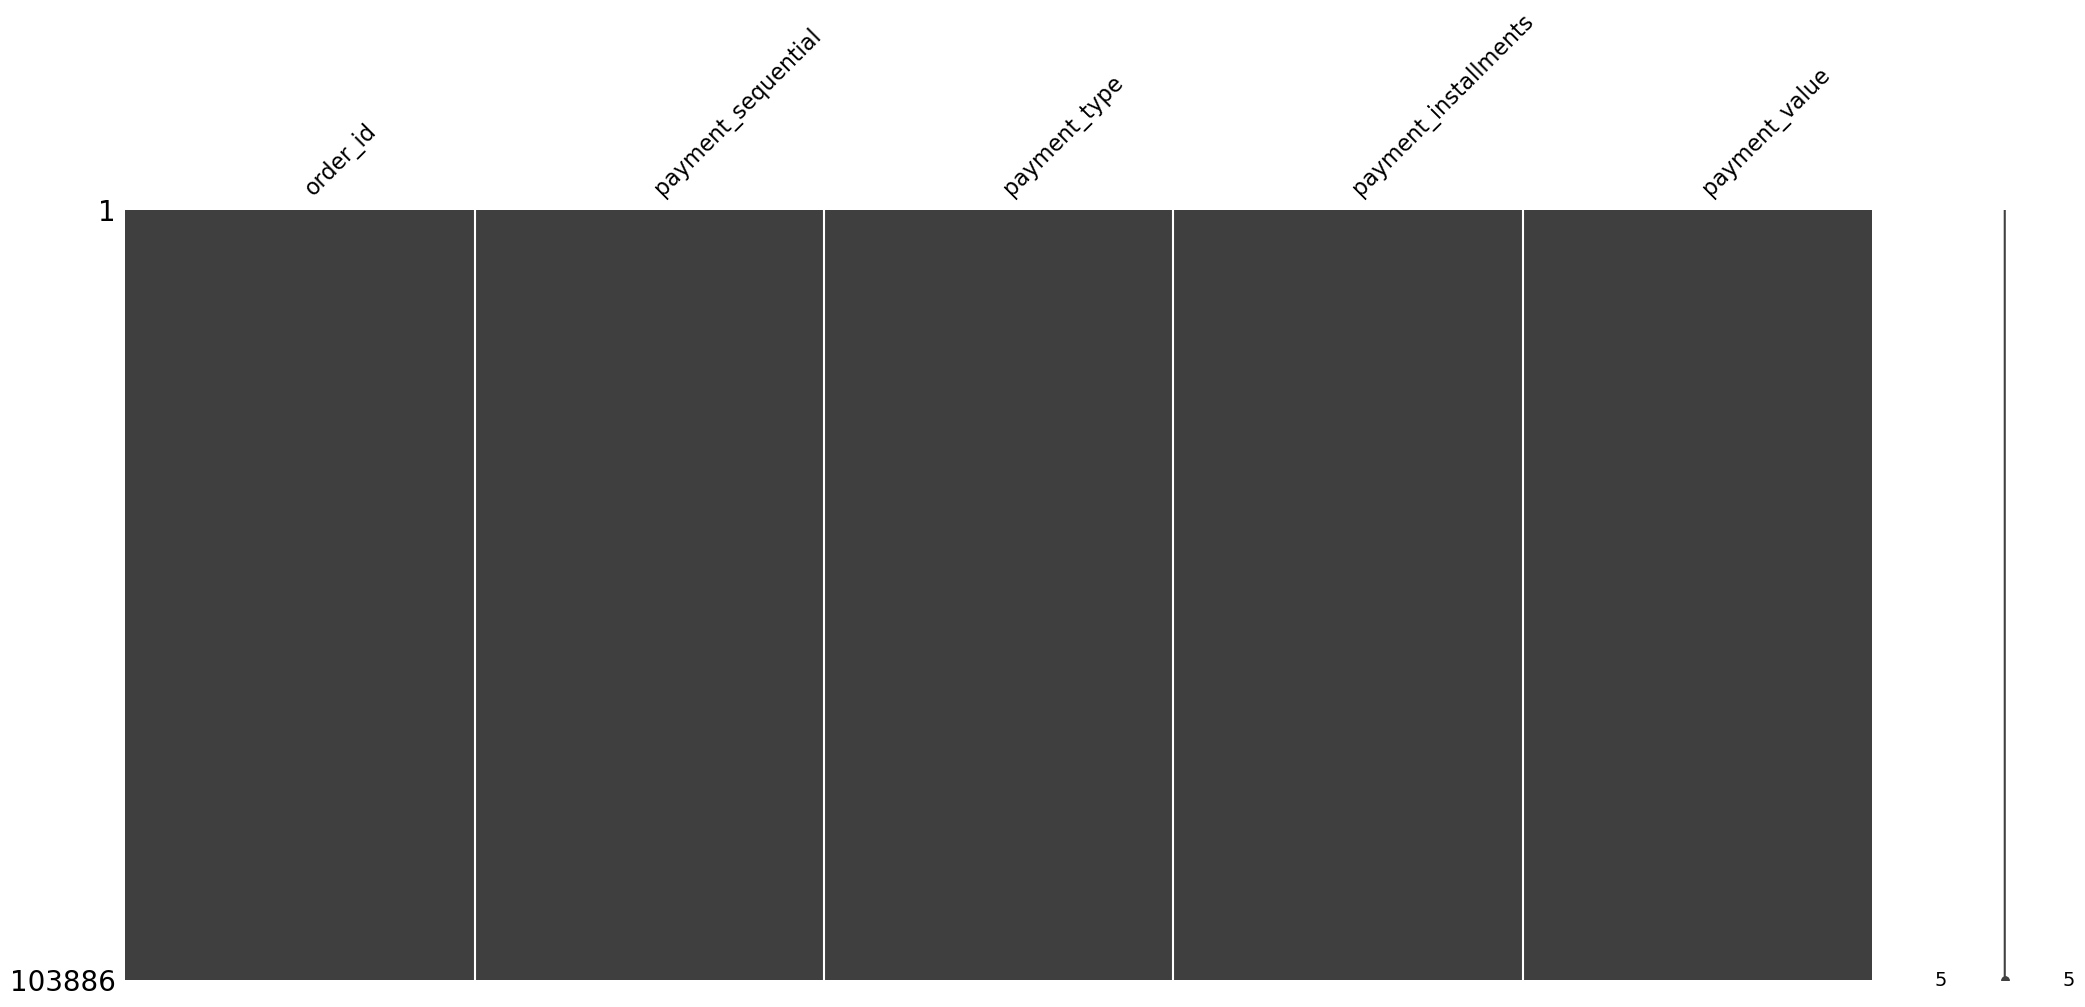

In [30]:
description_dataset(payments,matrix = True)

In [31]:
payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [32]:
payments['payment_value'].value_counts()

50.00      324
20.00      274
100.00     255
77.57      250
35.00      165
          ... 
264.64       1
1071.83      1
563.95       1
38.07        1
363.31       1
Name: payment_value, Length: 29077, dtype: int64

In [33]:
payments['payment_type'].value_counts()

credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: payment_type, dtype: int64

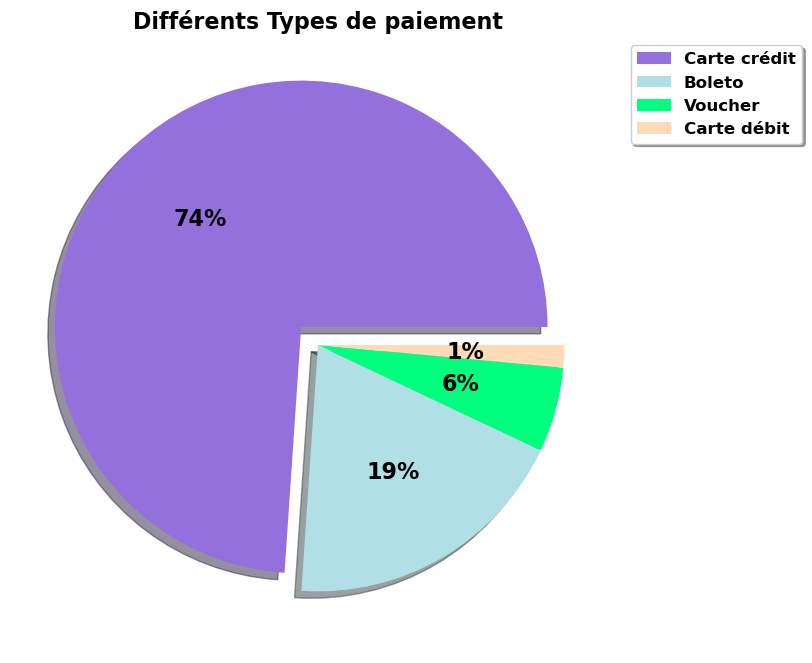

In [34]:
fig, ax = plt.subplots(figsize=(9, 8), subplot_kw=dict(aspect='equal'))
explode = (0.1, 0, 0, 0)
colors = ['MediumPurple', 'PowderBlue', 'SpringGreen', 'PeachPuff']
legend = ['Carte crédit', 'Boleto', 'Voucher',
          'Carte débit']

p = payments['payment_type'][payments['payment_type']
                                != 'not_defined'].value_counts()
p.plot(kind="pie", legend=False, labels=None, startangle=0,
       explode=explode, autopct='%1.0f%%', pctdistance=0.6, shadow=True,
       textprops={'weight': 'bold', 'fontsize': 16}, colors=colors,
       ax=ax)
ax.legend(legend, loc='best', shadow=True,
          prop={'weight': 'bold', 'size': 12},
          bbox_to_anchor=(0.8, 0, 0.5, 1))
plt.title('Différents Types de paiement', fontweight='bold', size=16)
plt.ylabel("")
plt.show()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24


Taille :-------------------------------------------------------------- (99224, 7)
----------------------------------------------------------------------------------------------------
Types :object    6
int64     1
dtype: int64
----------------------------------------------------------------------------------------------------
Types :review_id                  object
order_id                   object
review_score                int64
review_comment_title       object
review_comment_message     object
review_creation_date       object
review_answer_timestamp    object
dtype: object
----------------------------------------------------------------------------------------------------
Valeurs manquantes par colonnes (%): 
review_comment_title       88.34
review_comment_message     58.70
review_id                   0.00
order_id                    0.00
review_score                0.00
review_creation_date        0.00
review_answer_timestamp     0.00
dtype: float64
----------------------------

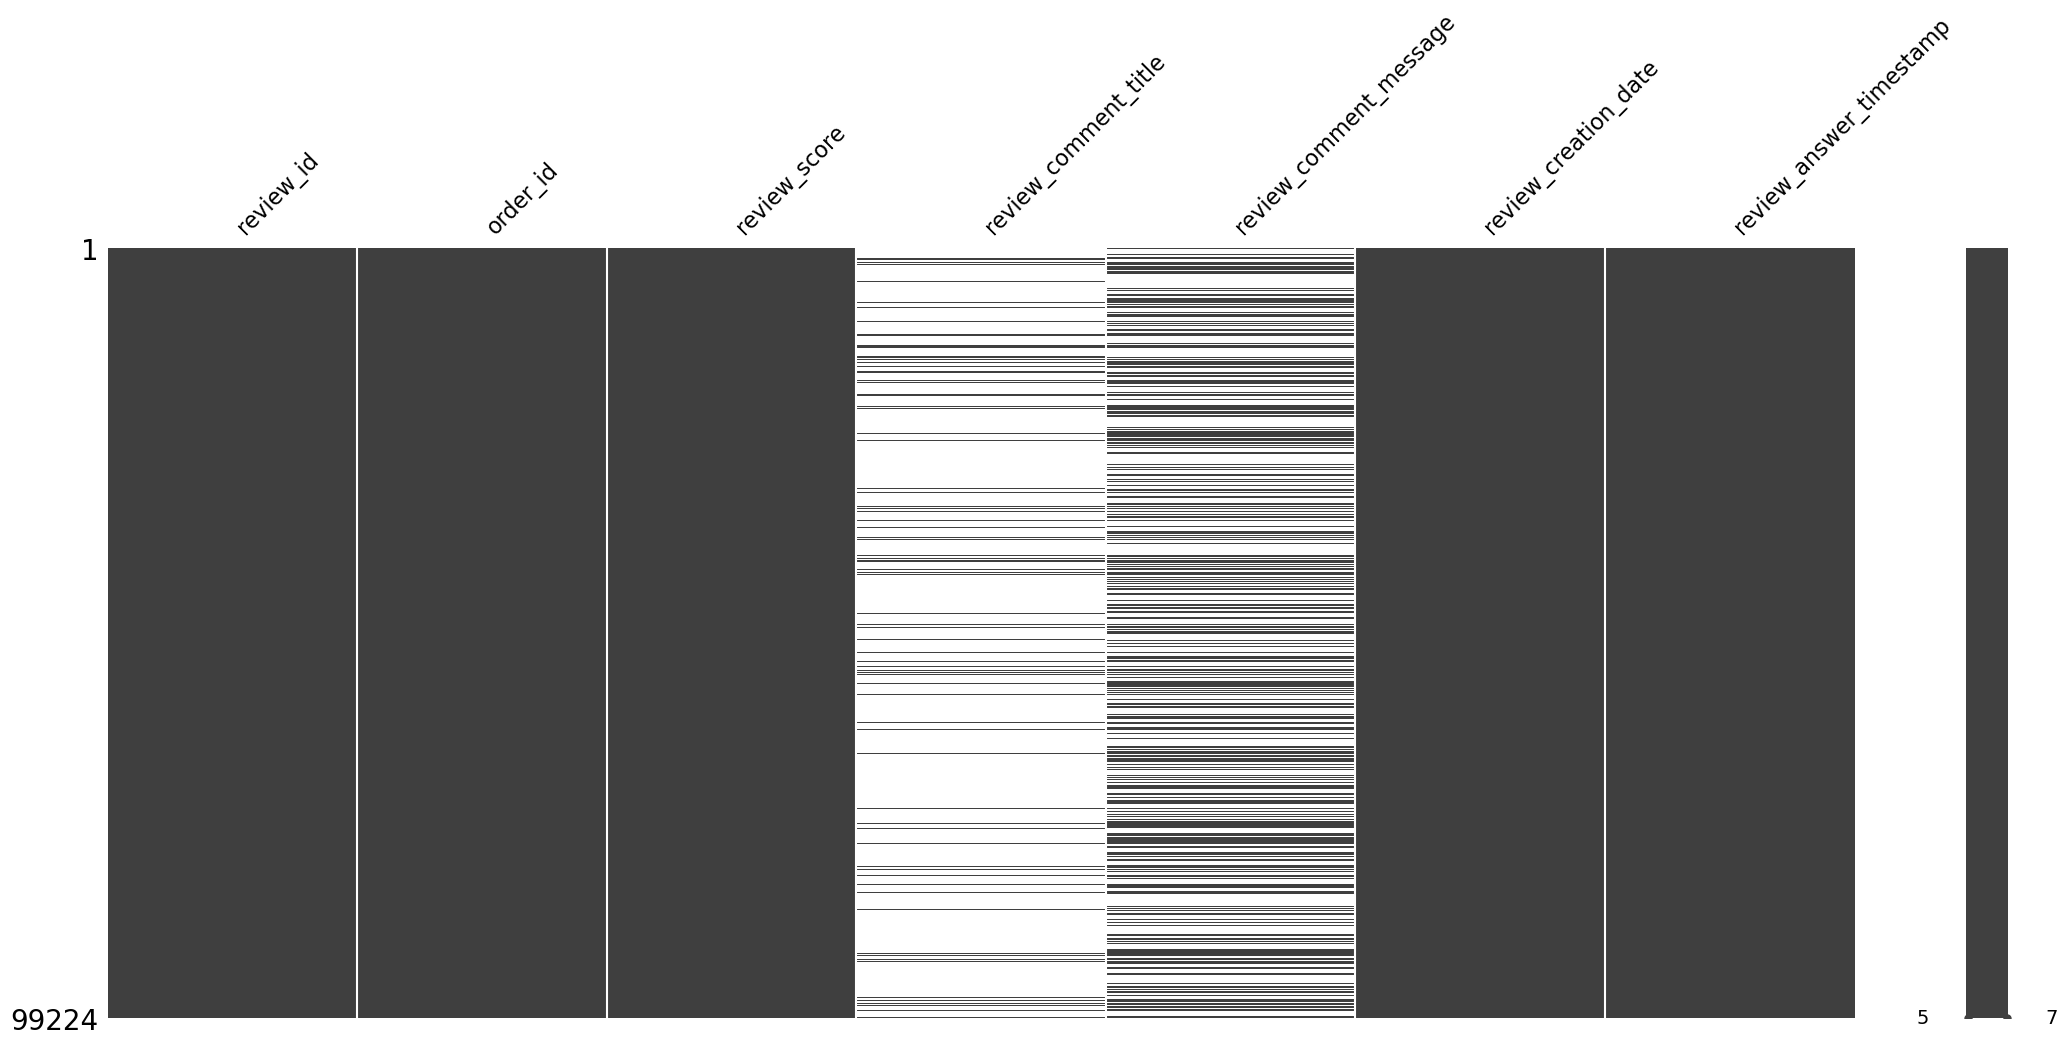

In [35]:

description_dataset(order_review, matrix= True)

In [36]:
order_review.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


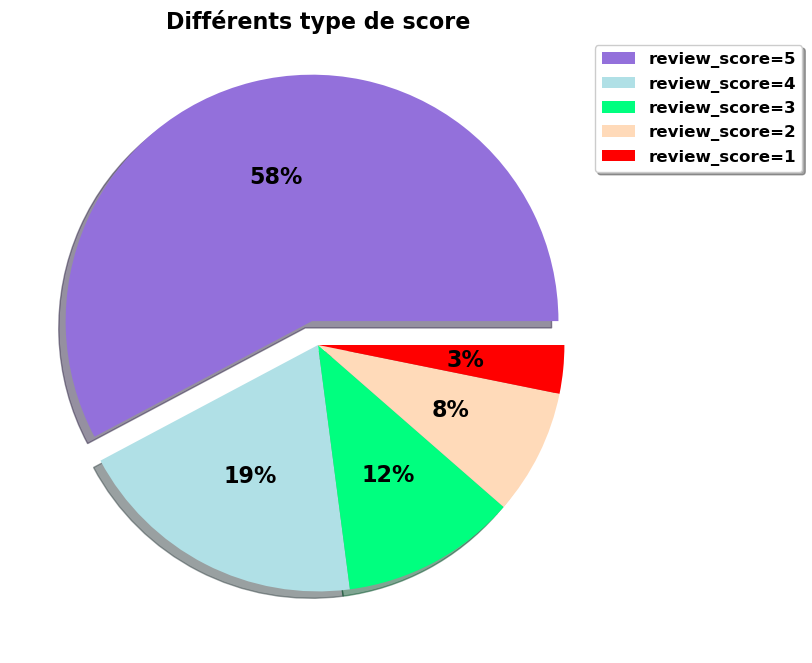

In [37]:
fig, ax = plt.subplots(figsize=(9, 8), subplot_kw=dict(aspect='equal'))
explode = (0.1, 0, 0, 0,0)
colors = ['MediumPurple', 'PowderBlue', 'SpringGreen', 'PeachPuff','red']
legend = ['review_score=5', 'review_score=4', 'review_score=3',
          'review_score=2','review_score=1']

p = order_review['review_score'][order_review['review_score']
                                != 'not_defined'].value_counts()
p.plot(kind="pie", legend=False, labels=None, startangle=0,
       explode=explode, autopct='%1.0f%%', pctdistance=0.6, shadow=True,
       textprops={'weight': 'bold', 'fontsize': 16}, colors=colors,
       ax=ax)
ax.legend(legend, loc='best', shadow=True,
          prop={'weight': 'bold', 'size': 12},
          bbox_to_anchor=(0.8, 0, 0.5, 1))
plt.title('Différents type de score', fontweight='bold', size=16)
plt.ylabel("")
plt.show()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


Taille :-------------------------------------------------------------- (99441, 5)
----------------------------------------------------------------------------------------------------
Types :object    4
int64     1
dtype: int64
----------------------------------------------------------------------------------------------------
Types :customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object
----------------------------------------------------------------------------------------------------
Valeurs manquantes par colonnes (%): 
customer_id                 0.0
customer_unique_id          0.0
customer_zip_code_prefix    0.0
customer_city               0.0
customer_state              0.0
dtype: float64
----------------------------------------------------------------------------------------------------
Valeurs différentes par variables : 
customer_id-------------

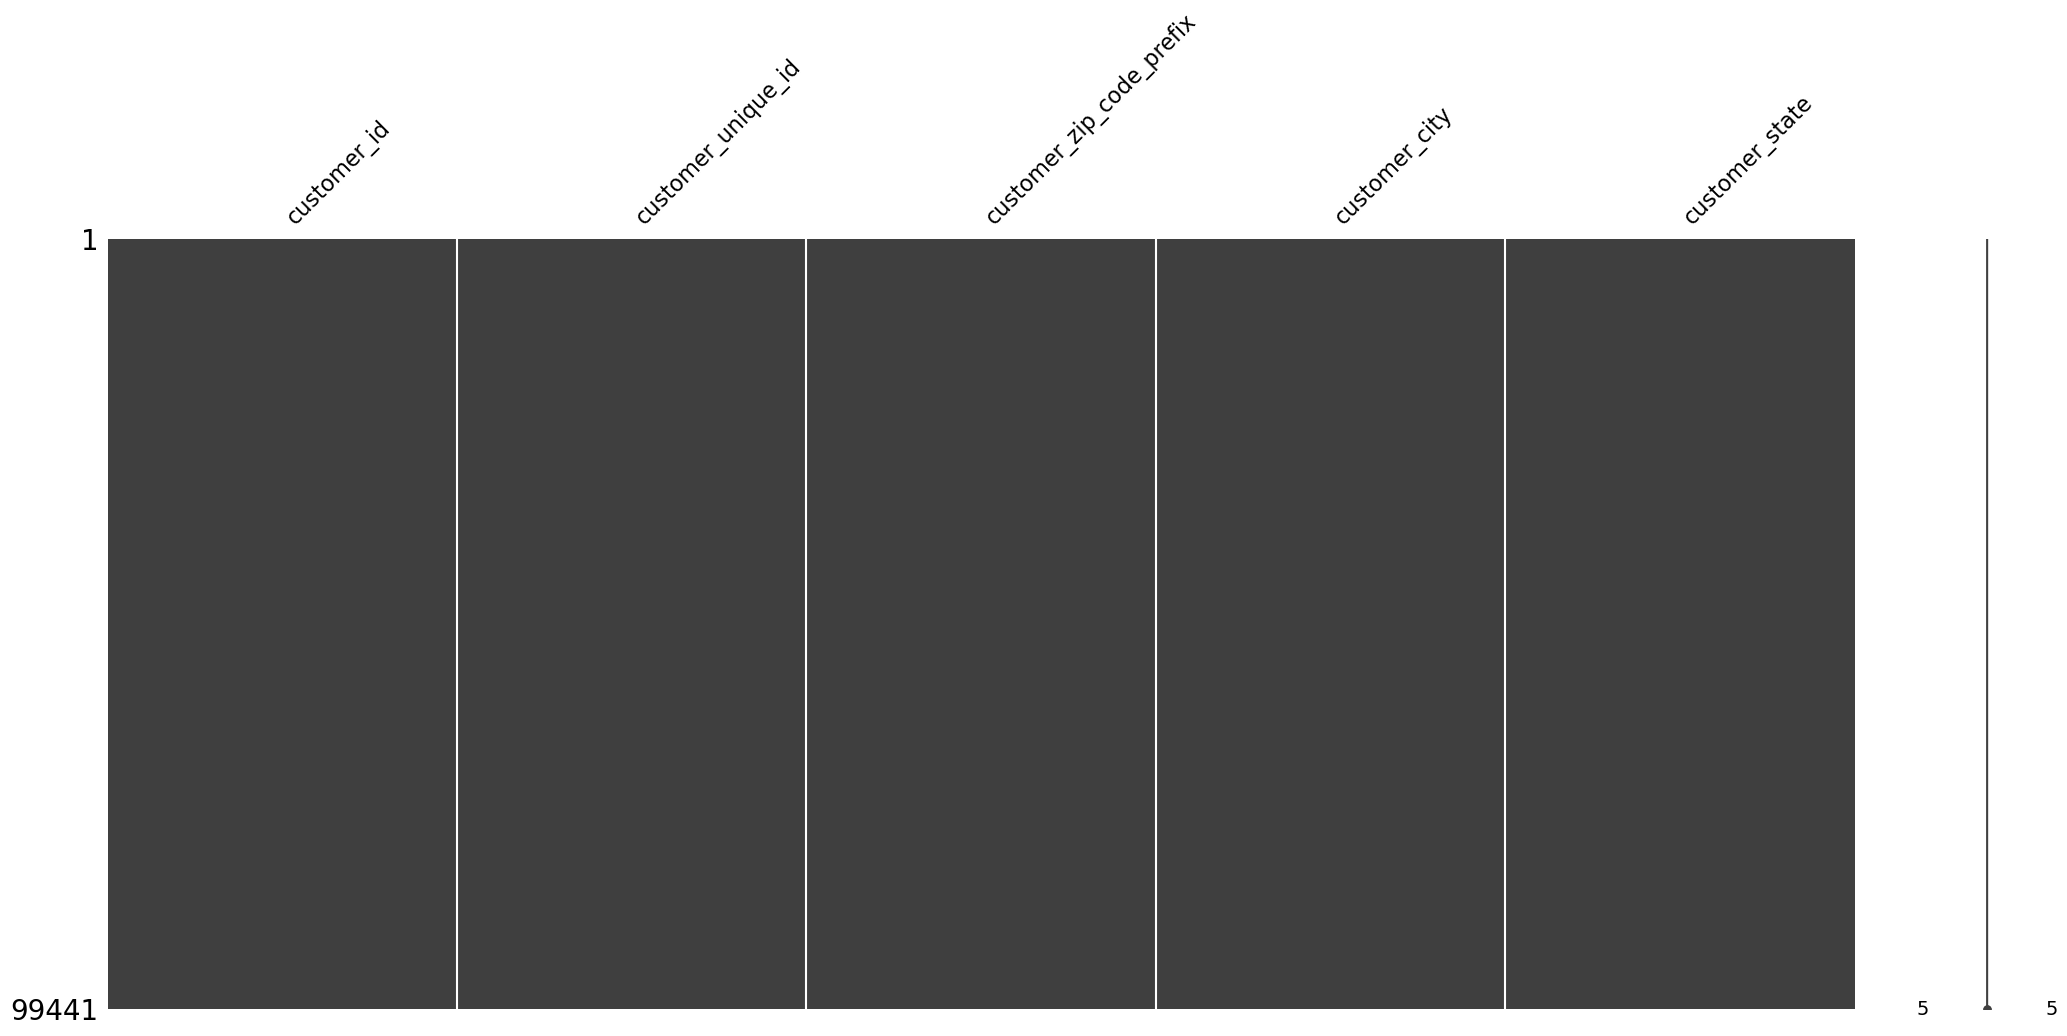

In [38]:
description_dataset(customer, matrix = True)

In [39]:
# voir pourquoi il y'a customer id et customer unique id:
#customer_id=99441
#customer_unique_id=96096

In [40]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [41]:
#for value in customer['customer_id']:
    #print (value)

In [42]:
customer['customer_id'].value_counts()

06b8999e2fba1a1fbc88172c00ba8bc7    1
c023f30c1147aeb0358474f3b1dbc707    1
b5cbf43f42281920a175fc99650c91d6    1
19f4e983f8f05b7de16670f8a0cf0ac7    1
229ac14c6ee6d6a606264ebcc861beb7    1
                                   ..
31665bd5bc542687ab54c9fd9ed9917b    1
37fb9cce079a4887c96b59bae2011d05    1
1d815f3ad9b2017b6da2c4f1cbb1180b    1
6b05c8f3a25a71005d5eb9b51766c333    1
274fa6071e5e17fe303b9748641082c8    1
Name: customer_id, Length: 99441, dtype: int64

In [43]:
customer['customer_unique_id'].value_counts()

8d50f5eadf50201ccdcedfb9e2ac8455    17
3e43e6105506432c953e165fb2acf44c     9
1b6c7548a2a1f9037c1fd3ddfed95f33     7
ca77025e7201e3b30c44b472ff346268     7
6469f99c1f9dfae7733b25662e7f1782     7
                                    ..
081f07439678af2da7755a0aa572154d     1
9c57789a6a587f4efcfb01e36c106014     1
9e4c21635f640562de1a6976374fba03     1
06c0ea6ee892364d1608ee47aa9f56a0     1
84732c5050c01db9b23e19ba39899398     1
Name: customer_unique_id, Length: 96096, dtype: int64

In [44]:
col_custumer=customer['customer_unique_id'].nunique()


In [45]:
col_custumer

96096

# customer_unique_id qu'il faudrait prendre en compte car c'est un identifiant unique or que custommer_id est généré pour chaque commande

In [46]:
df_cus = customer.groupby(['customer_unique_id']).count()
df_cus.customer_id.value_counts()

1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: customer_id, dtype: int64

In [47]:
df_cus.loc[ "b6c083700ca8c135ba9f0f132930d4e8"]

customer_id                 2
customer_zip_code_prefix    2
customer_city               2
customer_state              2
Name: b6c083700ca8c135ba9f0f132930d4e8, dtype: int64

In [48]:
df1 = customer.loc[customer['customer_unique_id'] == "b6c083700ca8c135ba9f0f132930d4e8"]

In [49]:
df1

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
132,f7c5afab273b47ab517e096e0219b932,b6c083700ca8c135ba9f0f132930d4e8,8686,suzano,SP
679,c57b4b6f3719475543b721e720a526ad,b6c083700ca8c135ba9f0f132930d4e8,8686,suzano,SP


# le nombre de client par code postal

In [50]:
    customer['customer_zip_code_prefix'].value_counts()

22790    142
24220    124
22793    121
24230    117
22775    110
        ... 
35698      1
99370      1
64808      1
60876      1
99043      1
Name: customer_zip_code_prefix, Length: 14994, dtype: int64

In [51]:
nombre_de_clients_par_code_postal =customer.groupby('customer_zip_code_prefix').size().reset_index(name='nombre_de_clients')

In [52]:
nombre_de_clients_par_code_postal

,customer_zip_code_prefix,nombre_de_clients
0,1003,1
1,1004,2
2,1005,6
3,1006,2
4,1007,4
...,...,...
14989,99960,2
14990,99965,2
14991,99970,1
14992,99980,2


In [53]:
nombre_de_clients_par_code_postal = nombre_de_clients_par_code_postal.sort_values(by='nombre_de_clients', ascending=False)

In [54]:
nombre_de_clients_par_code_postal

,customer_zip_code_prefix,nombre_de_clients
5885,22790,142
6027,24220,124
5886,22793,121
6028,24230,117
5880,22775,110
...,...,...
9910,58421,1
9904,58411,1
9897,58398,1
9895,58396,1


In [55]:
nombre_de_clients_par_code_postal=nombre_de_clients_par_code_postal.reset_index()

In [56]:
 nombre_de_clients_par_code_postal.head(10)

,index,customer_zip_code_prefix,nombre_de_clients
0,5885,22790,142
1,6027,24220,124
2,5886,22793,121
3,6028,24230,117
4,5880,22775,110
5,6827,29101,101
6,4387,13212,95
7,7469,35162,93
8,5855,22631,89
9,8138,38400,87


In [57]:
nombre_de_clients_par_code_postal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14994 entries, 0 to 14993
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   index                     14994 non-null  int64
 1   customer_zip_code_prefix  14994 non-null  int64
 2   nombre_de_clients         14994 non-null  int64
dtypes: int64(3)
memory usage: 351.6 KB


In [58]:
nombre_de_clients_par_code_postal['customer_zip_code_prefix'] = nombre_de_clients_par_code_postal['customer_zip_code_prefix'].astype(str)

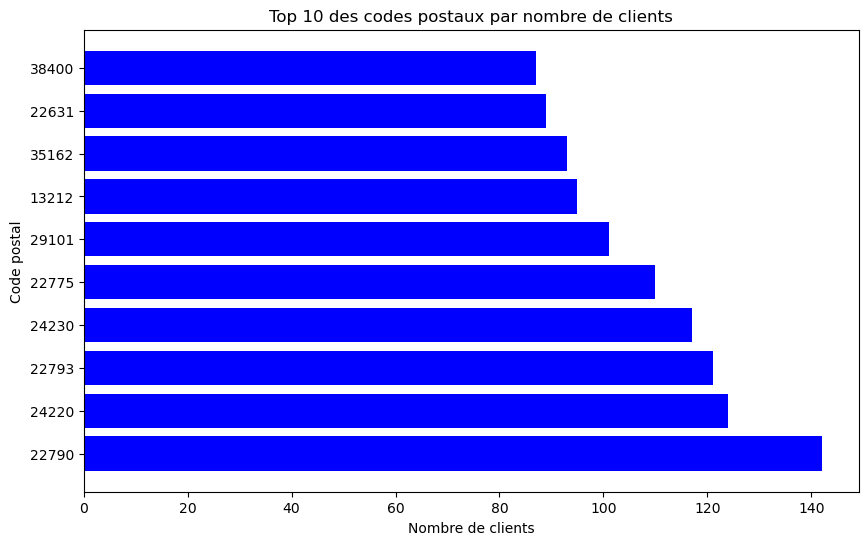

In [59]:
top_10 = nombre_de_clients_par_code_postal.head(10)

# Tracé du graphique en barres horizontales
plt.figure(figsize=(10, 6))  # Définition de la taille de la figure
plt.barh(top_10['customer_zip_code_prefix'], top_10['nombre_de_clients'], color='blue')
plt.xlabel('Nombre de clients')
plt.ylabel('Code postal')
plt.title('Top 10 des codes postaux par nombre de clients')
#plt.gca().invert_yaxis()  # Inversion de l'axe y pour avoir le code postal le plus élevé en haut
plt.show()

In [60]:
nombre_total_clients_par_ville = customer.groupby('customer_city').size().reset_index(name='nombre_total_clients')

In [61]:
nombre_total_clients_par_ville

,customer_city,nombre_total_clients
0,abadia dos dourados,3
1,abadiania,1
2,abaete,12
3,abaetetuba,11
4,abaiara,2
...,...,...
4114,xinguara,9
4115,xique-xique,3
4116,zacarias,2
4117,ze doca,5


In [62]:
nombre_total_clients_par_ville = nombre_total_clients_par_ville.sort_values(by='nombre_total_clients', ascending=False)

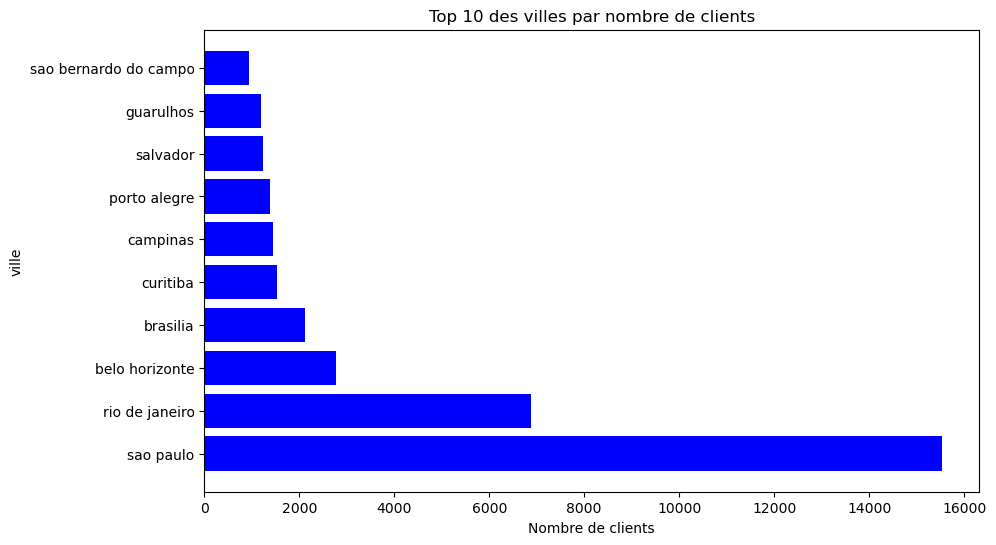

In [63]:
top_10 = nombre_total_clients_par_ville.head(10)

# Tracé du graphique en barres horizontales
plt.figure(figsize=(10, 6))  # Définition de la taille de la figure
plt.barh(top_10['customer_city'], top_10['nombre_total_clients'], color='blue')
plt.xlabel('Nombre de clients')
plt.ylabel('ville')
plt.title('Top 10 des villes par nombre de clients')
#plt.gca().invert_yaxis()  # Inversion de l'axe y pour avoir le code postal le plus élevé en haut
plt.show()

In [64]:

description_dataset(sellers, matrix = False)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ


Taille :-------------------------------------------------------------- (3095, 4)
----------------------------------------------------------------------------------------------------
Types :object    3
int64     1
dtype: int64
----------------------------------------------------------------------------------------------------
Types :seller_id                 object
seller_zip_code_prefix     int64
seller_city               object
seller_state              object
dtype: object
----------------------------------------------------------------------------------------------------
Valeurs manquantes par colonnes (%): 
seller_id                 0.0
seller_zip_code_prefix    0.0
seller_city               0.0
seller_state              0.0
dtype: float64
----------------------------------------------------------------------------------------------------
Valeurs différentes par variables : 
seller_id------------------------------------------------------------- contient 3095 valeurs différentes
sel

In [65]:
nombre_total_de_vendeurs_par_ville = sellers.groupby('seller_city').size().reset_index(name='nombre_total_vendeurs')

In [66]:
nombre_total_vendeurs_par_ville = nombre_total_de_vendeurs_par_ville.sort_values(by='nombre_total_vendeurs', ascending=False)

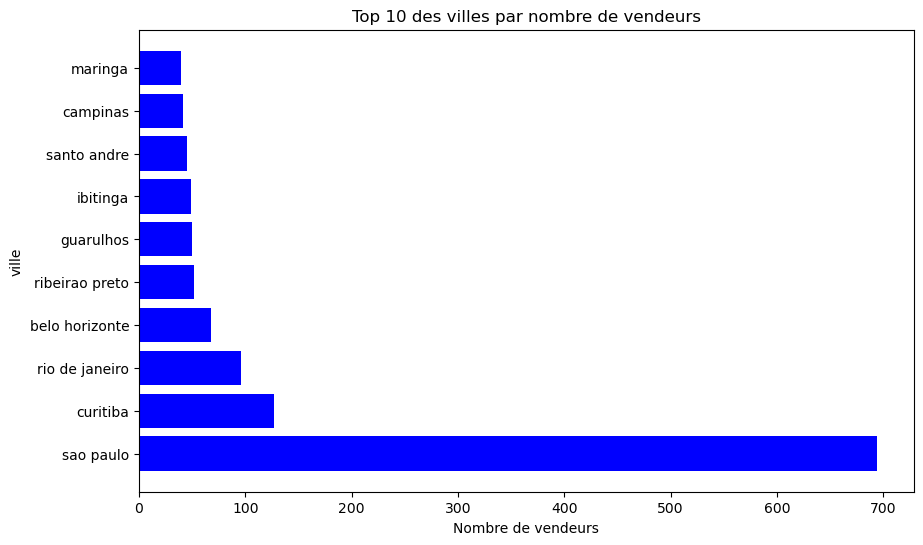

In [67]:
top_10 = nombre_total_vendeurs_par_ville.head(10)

# Tracé du graphique en barres horizontales
plt.figure(figsize=(10, 6))  # Définition de la taille de la figure
plt.barh(top_10['seller_city'], top_10['nombre_total_vendeurs'], color='blue')
plt.xlabel('Nombre de vendeurs')
plt.ylabel('ville')
plt.title('Top 10 des villes par nombre de vendeurs')
#plt.gca().invert_yaxis()  # Inversion de l'axe y pour avoir le code postal le plus élevé en haut
plt.show()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP


Taille :-------------------------------------------------------------- (1000163, 5)
----------------------------------------------------------------------------------------------------
Types :float64    2
object     2
int64      1
dtype: int64
----------------------------------------------------------------------------------------------------
Types :geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                object
geolocation_state               object
dtype: object
----------------------------------------------------------------------------------------------------
Valeurs manquantes par colonnes (%): 
geolocation_zip_code_prefix    0.0
geolocation_lat                0.0
geolocation_lng                0.0
geolocation_city               0.0
geolocation_state              0.0
dtype: float64
----------------------------------------------------------------------------------------------------
Valeurs d

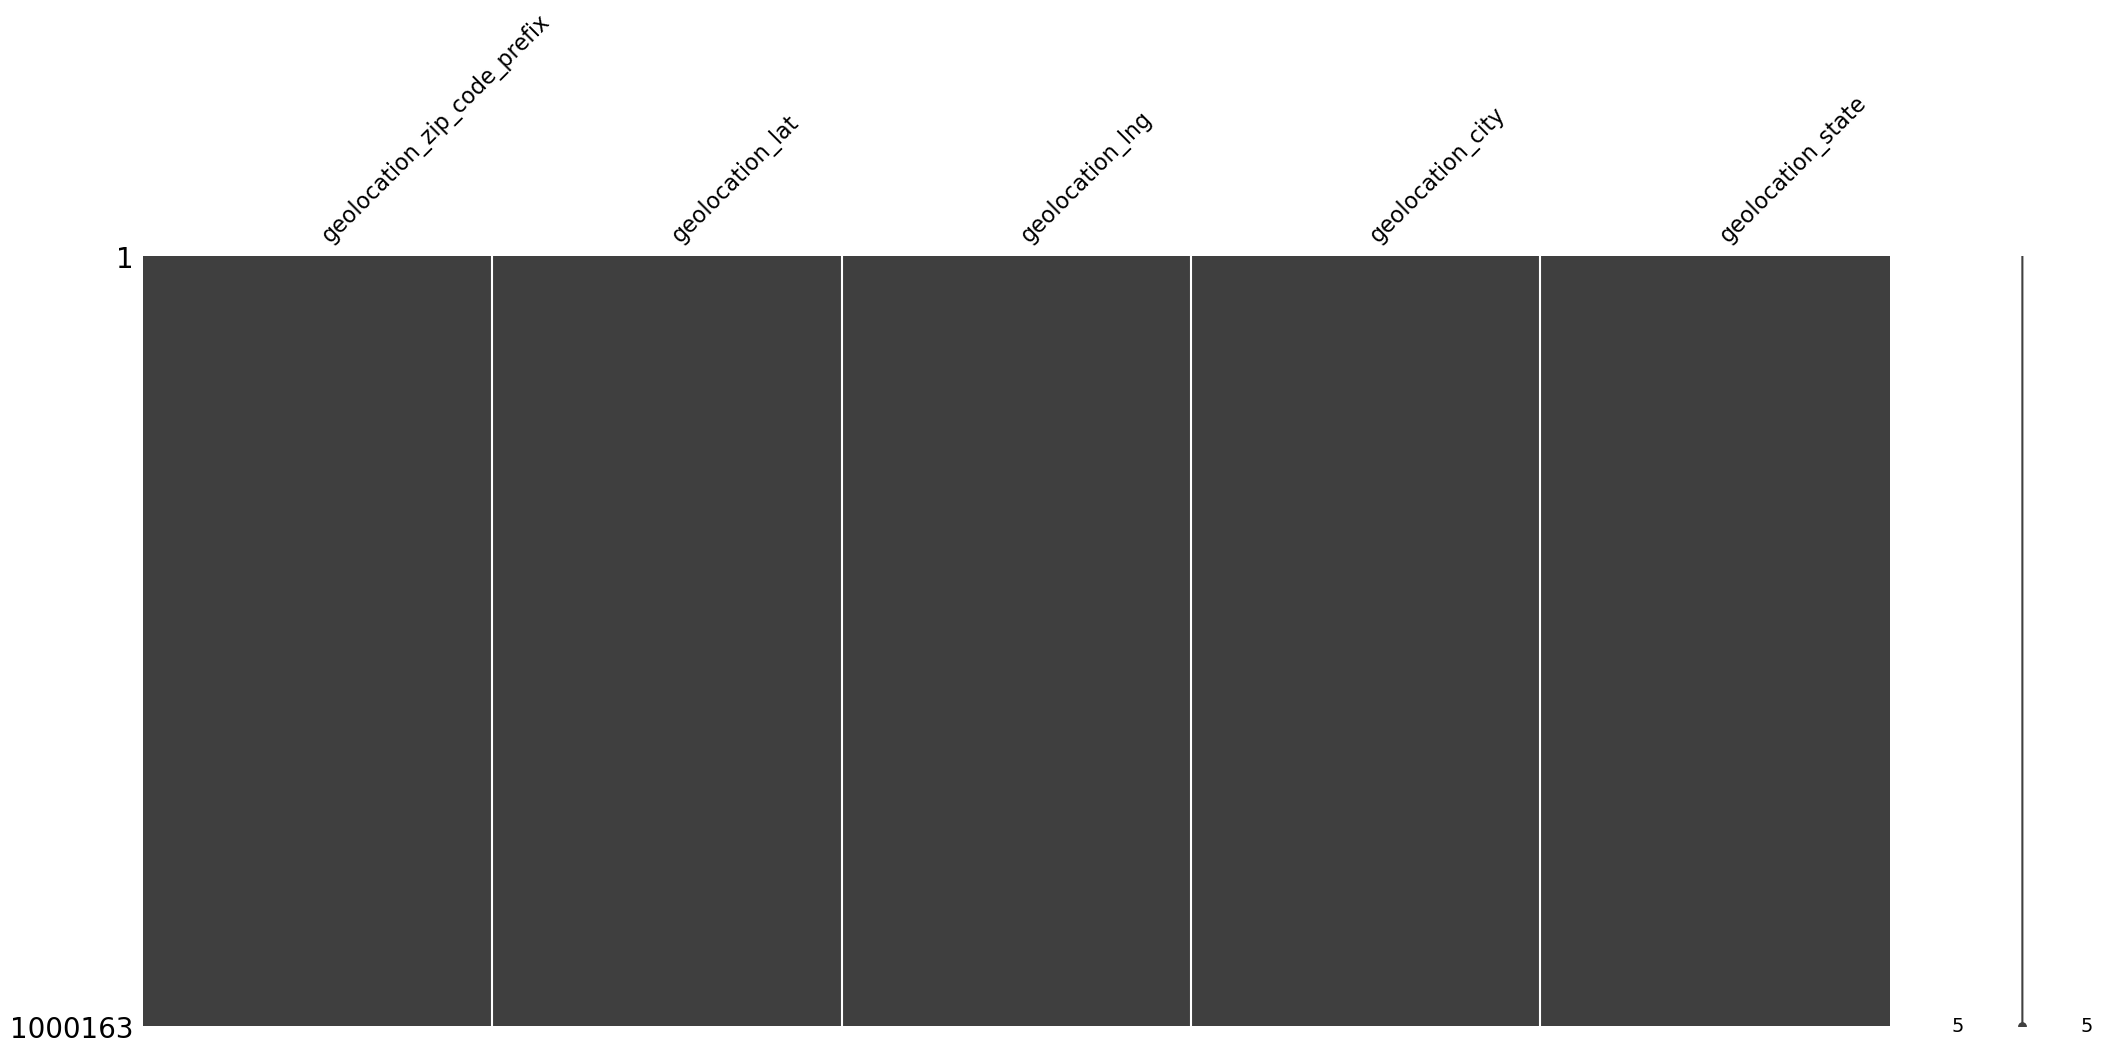

In [68]:

description_dataset(geolocation, matrix=True)

# Nettoyage données

In [69]:
#Duplicatas
geolocation.drop_duplicates(inplace = True)


In [70]:
geolocation.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 738332 entries, 0 to 1000161
Data columns (total 5 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   geolocation_zip_code_prefix  738332 non-null  int64  
 1   geolocation_lat              738332 non-null  float64
 2   geolocation_lng              738332 non-null  float64
 3   geolocation_city             738332 non-null  object 
 4   geolocation_state            738332 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 33.8+ MB


In [71]:
# Valeurs manquantes, on traite les variables succeptibles d'être utilisées
products.product_category_name.fillna("unknown", inplace = True)

order_review.fillna(" ", inplace= True)

orders['order_approved_at'].fillna(0, inplace=True) 
orders['order_delivered_carrier_date'].fillna(0, inplace=True)
orders['order_delivered_customer_date'].fillna(0, inplace=True)

In [72]:
# Traduction des noms de catégories des produits de portugais à anglais
# Fusion avec le jeu de données df_translation mais 71 catégories
# et 73 catégories dans df_products ==> 2 catégories à traduire
products = products.merge(
    category_name, on='product_category_name', how="left")

In [73]:
# Recherche des 2 catégories non traduites en anglais?
products[products['product_category_name_english']
            .isna() & products['product_category_name']
            .notnull()][['product_category_name',
                         'product_category_name_english']]

,product_category_name,product_category_name_english
105,unknown,NaN
128,unknown,NaN
145,unknown,NaN
154,unknown,NaN
197,unknown,NaN
...,...,...
32515,unknown,NaN
32589,unknown,NaN
32616,unknown,NaN
32772,unknown,NaN


In [74]:
# Imputation des valeurs manquantes de product_category_name_english
# grâce à la traduction portugais / anglais
products.loc[(products['product_category_name'] == 'pc_gamer'),
                'product_category_name_english'] = 'pc_gamer'
products.loc[(products['product_category_name'] ==
                 'portateis_cozinha_e_preparadores_de_alimentos'),
                'product_category_name_english'] = \
                'kitchen_laptops_and_food_preparers'

In [75]:
products['product_category_name_english'].nunique()

73

In [76]:
# Regroupement des catégories : de 73 modalités à modalités
dico_categories = {

    # Food
    'drinks': 'food',
    'food': 'food',
    'food_drink': 'food',
    'la_cuisine': 'food',
    'kitchen_laptops_and_food_preparers': 'food',

    # Fashion
    'fashio_female_clothing': 'fashion',
    'fashion_bags_accessories': 'fashion',
    'fashion_childrens_clothes': 'fashion',
    'fashion_male_clothing': 'fashion',
    'fashion_shoes': 'fashion',
    'fashion_sport': 'fashion',
    'fashion_underwear_beach': 'fashion',
    'health_beauty': 'fashion',
    'perfumery': 'fashion',
    'diapers_and_hygiene': 'fashion',
    'baby': 'fashion',
    'luggage_accessories': 'fashion',

    # leisure
    'sports_leisure': 'leisure',
    'consoles_games': 'leisure',
    'musical_instruments': 'leisure',
    'toys': 'leisure',
    'cine_photo': 'leisure',
    'dvds_blu_ray': 'leisure',
    'cds_dvds_musicals': 'leisure',
    'music': 'leisure',
    'books_general_interest': 'leisure',
    'books_imported': 'leisure',
    'books_technical': 'leisure',

    # Home
    'furniture_bedroom': 'home',
    'furniture_decor': 'home',
    'furniture_living_room': 'home',
    'furniture_mattress_and_upholstery': 'home',
    'bed_bath_table': 'home',
    'christmas_supplies': 'misc',
    'kitchen_dining_laundry_garden_furniture': 'home',
    'office_furniture': 'home',
    'home_appliances': 'home',
    'home_appliances_2': 'home',
    'home_comfort_2': 'home',
    'home_confort': 'home',
    'air_conditioning': 'home',
    'housewares': 'home',
    'art': 'home',
    'arts_and_craftmanship': 'home',
    'party_supplies': 'misc',
    'flowers': 'home',
    'cool_stuff': 'home',

    # Construction
    'construction_tools_construction': 'construction',
    'construction_tools_lights': 'construction',
    'construction_tools_safety': 'construction',
    'costruction_tools_garden': 'construction',
    'costruction_tools_tools': 'construction',
    'garden_tools': 'construction',
    'home_construction': 'construction',

    # High technology
    'electronics': 'high_technology',
    'audio': 'high_technology',
    'tablets_printing_image': 'high_technology',
    'telephony': 'high_technology',
    'fixed_telephony': 'high_technology',
    'small_appliances': 'high_technology',
    'small_appliances_home_oven_and_coffee': 'high_technology',
    'computers_accessories': 'high_technology',
    'computers': 'high_technology',
    'security_and_services': 'misc',
    'signaling_and_security': 'misc',

    # Misc
    'stationery': 'misc',
    'auto': 'misc',
    'watches_gifts': 'misc',
    'agro_industry_and_commerce': 'misc',
    'industry_commerce_and_business': 'misc',
    'market_place': 'misc',
    'pet_shop': 'misc',
    'other': 'misc'
}

In [77]:
# Regroupement des modalités
products['product_category_name_english'] = \
   products['product_category_name_english'].map(dico_categories)

In [78]:
products['product_category_name_english'].unique()

array(['fashion', 'home', 'leisure', 'construction', 'high_technology',
       'misc', nan, 'food'], dtype=object)

In [79]:
# refiare ce graphique en intégrant la fonction 

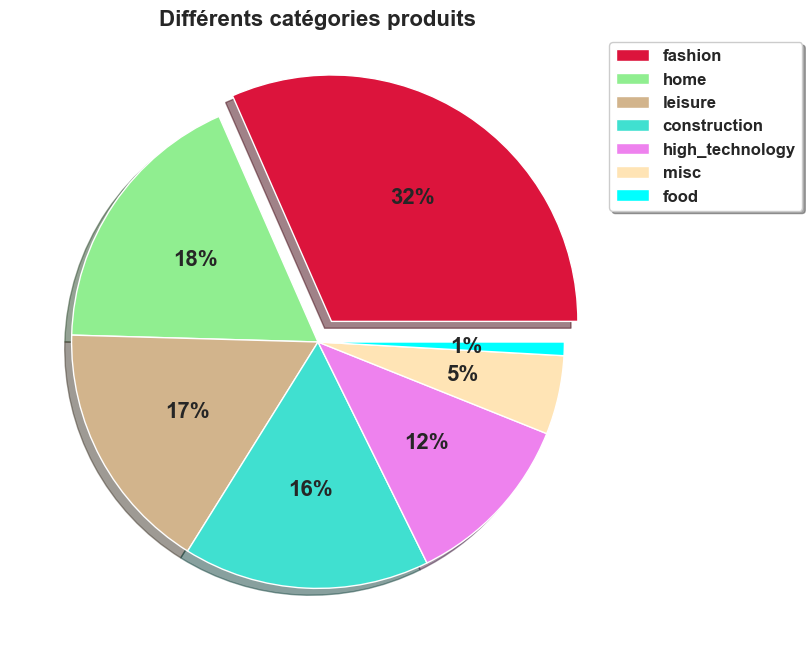

In [196]:
fig, ax = plt.subplots(figsize=(9, 8), subplot_kw=dict(aspect='equal'))
explode = (0.1, 0, 0, 0,0,0,0)
colors = ['Crimson', 'LightGreen', 'Tan', 'Turquoise', 'Violet',
                 'Moccasin', 'Aqua']
legend = ['fashion', 'home', 'leisure', 'construction', 'high_technology',
       'misc',  'food']

p = products['product_category_name_english'][products['product_category_name_english']
                                != 'nan'].value_counts()

p.plot(kind="pie", legend=False, labels=None, startangle=0,
       explode=explode, autopct='%1.0f%%', pctdistance=0.6, shadow=True,
       textprops={'weight': 'bold', 'fontsize': 16}, colors=colors,
       ax=ax)
ax.legend(legend, loc='best', shadow=True,
          prop={'weight': 'bold', 'size': 12},
          bbox_to_anchor=(0.8, 0, 0.5, 1))
plt.title('Différents catégories produits', fontweight='bold', size=16)
plt.ylabel("")
plt.show()

In [81]:
# Suppression des variables inutiles pour notre étude (catégorie en portugais,
# les tailles des descriptions, la taille du produit)
products = products.drop(['product_category_name',
                                'product_name_lenght',
                                'product_description_lenght',
                                'product_photos_qty',
                                'product_weight_g', 'product_length_cm',
                                'product_height_cm', 'product_width_cm'],
                               axis=1)

In [82]:
# Les jointures

In [83]:
df1 = pd.merge(customer, orders, on='customer_id', how='left')
df1.shape

(99441, 12)

In [84]:
# Regrouper les latitudes/longitudes par leurs moyennes
geolocation = geolocation.groupby('geolocation_zip_code_prefix') \
    .agg({'geolocation_lat': 'mean', 'geolocation_lng': 'mean',
          'geolocation_city': 'first', 'geolocation_state': 'first'}) \
    .reset_index()
# Vérification
geolocation['geolocation_zip_code_prefix'].nunique()

19015

In [85]:
geolocation.drop(columns=['geolocation_state'], inplace=True)

In [86]:
# Fusion des jeux de données : df1 et df_geolocation
# Variables de jointure : df1.customer_zip_code_prefix
#                      et df_geolocation.geolocation_zip_code_prefix
df2 = pd.merge(df1, geolocation, left_on='customer_zip_code_prefix',
               right_on='geolocation_zip_code_prefix', how='left')
df2.shape

(99441, 16)

In [87]:
df3 = pd.merge(df2, order_review, on='order_id', how='left')
df3.shape

(99992, 22)

In [88]:
df4 = pd.merge(df3, order_item, on='order_id', how='left')
df3.shape

(99992, 22)

In [89]:
df5 = pd.merge(df4, payments, on='order_id', how='left')
df5.shape

(119143, 32)

In [90]:
df = pd.merge(df5, products, on='product_id', how='left')
df.shape

(119143, 33)

In [91]:
df.head(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,product_category_name_english
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,00e7ee1b050b8499577073aeb2a297a1,delivered,2017-05-16 15:05:35,2017-05-16 15:22:12,2017-05-23 10:47:57,...,a9516a079e37a9c9c36b9b78b10169e8,7c67e1448b00f6e969d365cea6b010ab,2017-05-22 15:22:12,124.99,21.88,1.0,credit_card,2.0,146.87,home
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,29150127e6685892b6eab3eec79f59c7,delivered,2018-01-12 20:48:24,2018-01-12 20:58:32,2018-01-15 17:14:59,...,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-01-18 20:58:32,289.00,46.48,1.0,credit_card,8.0,335.48,home
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,b2059ed67ce144a36e2aa97d2c9e9ad2,delivered,2018-05-19 16:07:45,2018-05-20 16:19:10,2018-06-11 14:31:00,...,bd07b66896d6f1494f5b86251848ced7,7c67e1448b00f6e969d365cea6b010ab,2018-06-05 16:19:10,139.94,17.79,1.0,credit_card,7.0,157.73,home
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,951670f92359f4fe4a63112aa7306eba,delivered,2018-03-13 16:06:38,2018-03-13 17:29:19,2018-03-27 23:22:42,...,a5647c44af977b148e0a3a4751a09e2e,7c67e1448b00f6e969d365cea6b010ab,2018-03-27 16:31:16,149.94,23.36,1.0,credit_card,1.0,173.30,home
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,6b7d50bd145f6fc7f33cebabd7e49d0f,delivered,2018-07-29 09:51:30,2018-07-29 10:10:09,2018-07-30 15:16:00,...,9391a573abe00141c56e38d84d7d5b3b,4a3ca9315b744ce9f8e9374361493884,2018-07-31 10:10:09,230.00,22.25,1.0,credit_card,8.0,252.25,home


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 119143 entries, 0 to 119142
Data columns (total 33 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   customer_id                    119143 non-null  object        
 1   customer_unique_id             119143 non-null  object        
 2   customer_zip_code_prefix       119143 non-null  int64         
 3   customer_city                  119143 non-null  object        
 4   customer_state                 119143 non-null  object        
 5   order_id                       119143 non-null  object        
 6   order_status                   119143 non-null  object        
 7   order_purchase_timestamp       119143 non-null  datetime64[ns]
 8   order_approved_at              119143 non-null  object        
 9   order_delivered_carrier_date   119143 non-null  object        
 10  order_delivered_customer_date  119143 non-null  object        
 11  

In [93]:
df['order_approved_at']=df['order_approved_at'].apply(pd.to_datetime)

In [94]:
df['order_delivered_carrier_date']=df['order_delivered_carrier_date'].apply(pd.to_datetime)

In [95]:
df['order_delivered_customer_date']=df['order_delivered_customer_date'].apply(pd.to_datetime)

# les 1ere date

In [98]:
# Affichage des "premières" dates par colonne type
df[[
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]].min()

order_purchase_timestamp        2016-09-04 21:15:19
order_approved_at               1970-01-01 00:00:00
order_delivered_carrier_date    1970-01-01 00:00:00
order_delivered_customer_date   1970-01-01 00:00:00
order_estimated_delivery_date   2016-09-30 00:00:00
dtype: datetime64[ns]

ces dates 1970 

les dernières dates

In [99]:
# Affichage des "dernières" dates par colonne type
df[[
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]].max()

order_purchase_timestamp        2018-10-17 17:30:18
order_approved_at               2018-09-03 17:40:06
order_delivered_carrier_date    2018-09-11 19:48:28
order_delivered_customer_date   2018-10-17 13:22:46
order_estimated_delivery_date   2018-11-12 00:00:00
dtype: datetime64[ns]

# les dernières dates

In [100]:
# Affichage des "dernières" dates par colonne type
df[[
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]].max()

order_purchase_timestamp        2018-10-17 17:30:18
order_approved_at               2018-09-03 17:40:06
order_delivered_carrier_date    2018-09-11 19:48:28
order_delivered_customer_date   2018-10-17 13:22:46
order_estimated_delivery_date   2018-11-12 00:00:00
dtype: datetime64[ns]

In [101]:
last_order = df.order_purchase_timestamp.max()

In [102]:
last_order

Timestamp('2018-10-17 17:30:18')

In [103]:
df['days_since_last_order'] = (last_order - df.order_purchase_timestamp).astype('timedelta64[D]')

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 119143 entries, 0 to 119142
Data columns (total 34 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   customer_id                    119143 non-null  object        
 1   customer_unique_id             119143 non-null  object        
 2   customer_zip_code_prefix       119143 non-null  int64         
 3   customer_city                  119143 non-null  object        
 4   customer_state                 119143 non-null  object        
 5   order_id                       119143 non-null  object        
 6   order_status                   119143 non-null  object        
 7   order_purchase_timestamp       119143 non-null  datetime64[ns]
 8   order_approved_at              119143 non-null  datetime64[ns]
 9   order_delivered_carrier_date   119143 non-null  datetime64[ns]
 10  order_delivered_customer_date  119143 non-null  datetime64[ns]
 11  

In [105]:
# Affichage de la fréquence (par jour) des commandes clients (sans distinction) -> Validé ou non
df_order_freq =df.groupby(df['order_purchase_timestamp'].dt.date)['order_id'].agg('count')

In [106]:
df_order_freq

order_purchase_timestamp
2016-09-04    2
2016-09-05    1
2016-09-13    1
2016-09-15    3
2016-10-02    1
             ..
2018-09-29    1
2018-10-01    1
2018-10-03    1
2018-10-16    1
2018-10-17    1
Name: order_id, Length: 634, dtype: int64

In [107]:
print("Nombre maximum de commandes en une journée sur 2 ans : ", df_order_freq.max())

Nombre maximum de commandes en une journée sur 2 ans :  1435


In [108]:
idx_max_orders = df_order_freq[df_order_freq == df_order_freq.max()].index[0]
date_max_orders = idx_max_orders.strftime('%d/%m/%Y')

In [109]:
date_max_orders

'24/11/2017'

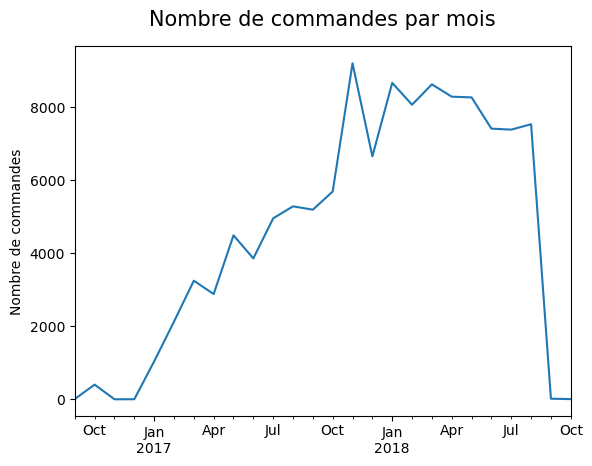

In [110]:
df_orders_month = pd.DataFrame(df_order_freq)
df_orders_month.index = pd.to_datetime(df_orders_month.index) # format en datetimeindex avec secondes

df_orders_month['order_id'].resample('M').sum().plot()
plt.title("Nombre de commandes par mois", fontsize=15, pad=15)
plt.xlabel("")
plt.ylabel("Nombre de commandes")

plt.show()

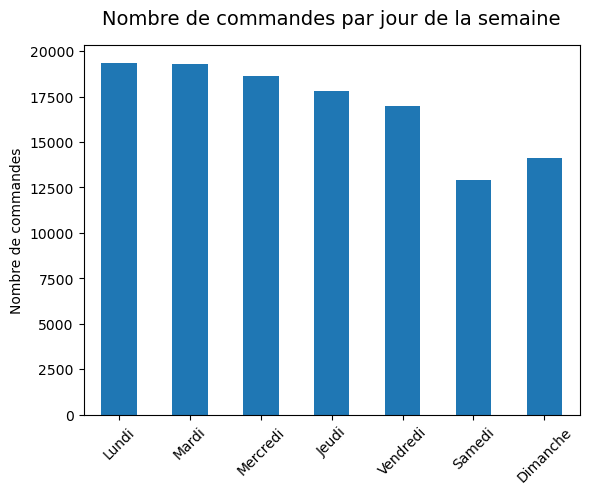

In [111]:
ds_orders_weekday = df_orders_month.groupby(df_orders_month.index.strftime("%A"))['order_id'].agg('sum')\
.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
ds_orders_weekday.plot(kind='bar', rot=45)

plt.title("Nombre de commandes par jour de la semaine", fontsize=14, pad=15)
plt.xlabel("")
plt.ylabel("Nombre de commandes")
plt.xticks(
    range(0, len(ds_orders_weekday)),
    ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
)

plt.show()

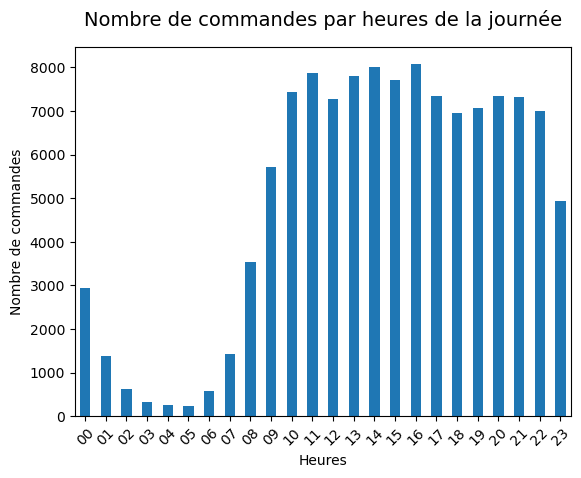

In [112]:
# Heures où les commandes sont passées

ds_orders_hourly = \
df.groupby(df['order_purchase_timestamp'].dt.strftime("%H"))['order_id'].count()

ds_orders_hourly.plot(kind='bar', rot=45)
plt.title("Nombre de commandes par heures de la journée", fontsize=14, pad=15)
plt.xlabel("Heures")
plt.ylabel("Nombre de commandes")

plt.show()

In [113]:
df_orders_freq = df.sort_values(by='order_purchase_timestamp').copy()

In [114]:
df_orders_freq.head(10)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,product_category_name_english,days_since_last_order
101541,08c5351a6aca1c1589a38f244edeee9d,b7d76e111c89f7ebf14761390f0f7d17,69309,boa vista,RR,2e7a8482f6fb09756ca50c10d7bfc047,shipped,2016-09-04 21:15:19,2016-10-07 13:18:03,2016-10-18 13:14:51,...,1554a68530182680ad5c8b042c3ab563,2016-10-26 18:25:19,32.90,31.67,1.0,credit_card,1.0,136.23,home,772.0
101540,08c5351a6aca1c1589a38f244edeee9d,b7d76e111c89f7ebf14761390f0f7d17,69309,boa vista,RR,2e7a8482f6fb09756ca50c10d7bfc047,shipped,2016-09-04 21:15:19,2016-10-07 13:18:03,2016-10-18 13:14:51,...,1554a68530182680ad5c8b042c3ab563,2016-10-26 18:25:19,39.99,31.67,1.0,credit_card,1.0,136.23,home,772.0
84557,683c54fc24d40ee9f8a6fc179fd9856c,4854e9b3feff728c13ee5fc7d1547e92,99025,passo fundo,RS,e5fa5a7210941f7d56d0208e4e071d35,canceled,2016-09-05 00:15:34,2016-10-07 13:17:15,1970-01-01 00:00:00,...,a425f92c199eb576938df686728acd20,2016-09-19 00:15:34,59.50,15.56,1.0,credit_card,3.0,75.06,high_technology,772.0
101720,622e13439d6b5a0b486c435618b2679e,009b0127b727ab0ba422f6d9604487c7,12244,sao jose dos campos,SP,809a282bbd5dbcabb6f2f724fca862ec,canceled,2016-09-13 15:24:19,2016-10-07 13:16:46,1970-01-01 00:00:00,...,NaN,NaN,NaN,NaN,1.0,credit_card,2.0,40.95,NaN,764.0
25366,86dc2ffce2dfff336de2f386a786e574,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,bfbd0f9bdef84302105ad712db648a6c,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,...,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83,NaN,NaN,NaN,NaN,fashion,762.0
25365,86dc2ffce2dfff336de2f386a786e574,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,bfbd0f9bdef84302105ad712db648a6c,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,...,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83,NaN,NaN,NaN,NaN,fashion,762.0
25367,86dc2ffce2dfff336de2f386a786e574,830d5b7aaa3b6f1e9ad63703bec97d23,14600,sao joaquim da barra,SP,bfbd0f9bdef84302105ad712db648a6c,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,...,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83,NaN,NaN,NaN,NaN,fashion,762.0
108254,b106b360fe2ef8849fbbd056f777b4d5,0eb1ee9dba87f5b36b4613a65074337c,2975,sao paulo,SP,71303d7e93b399f5bcd537d124c0bcfa,canceled,2016-10-02 22:07:52,2016-10-06 15:50:56,1970-01-01 00:00:00,...,25e6ffe976bd75618accfe16cefcbd0d,2016-10-21 16:19:54,100.00,9.34,1.0,credit_card,1.0,109.34,fashion,744.0
46382,355077684019f7f60a031656bd7262b8,32ea3bdedab835c3aa6cb68ce66565ef,4106,sao paulo,SP,3b697a20d9e427646d92567910af6d57,delivered,2016-10-03 09:44:50,2016-10-06 15:50:54,2016-10-23 14:02:13,...,522620dcb18a6b31cd7bdf73665113a9,2016-10-21 16:27:20,29.90,15.56,1.0,boleto,1.0,45.46,misc,744.0
66097,7ec40b22510fdbea1b08921dd39e63d8,2f64e403852e6893ae37485d5fcacdaf,98280,panambi,RS,be5bc2f0da14d8071e2d45451ad119d9,delivered,2016-10-03 16:56:50,2016-10-06 16:03:44,2016-10-21 16:33:46,...,f09b760d23495ac9a7e00d29b769007c,2016-10-21 16:33:46,21.90,17.19,1.0,boleto,1.0,39.09,leisure,744.0


In [115]:
df_orders_freq['order_freq'] = df_orders_freq['order_purchase_timestamp'].diff()

In [116]:
df_orders_freq['order_freq']

101541                NaT
101540    0 days 00:00:00
84557     0 days 03:00:15
101720    8 days 15:08:45
25366     1 days 20:52:19
               ...       
91147     3 days 00:32:48
91052     2 days 06:17:06
81825     2 days 03:25:20
82844    13 days 01:20:33
102435    0 days 21:14:16
Name: order_freq, Length: 119143, dtype: timedelta64[ns]

In [117]:
df_orders_freq[['order_purchase_timestamp', 'order_freq']].head()

,order_purchase_timestamp,order_freq
101541,2016-09-04 21:15:19,NaT
101540,2016-09-04 21:15:19,0 days 00:00:00
84557,2016-09-05 00:15:34,0 days 03:00:15
101720,2016-09-13 15:24:19,8 days 15:08:45
25366,2016-09-15 12:16:38,1 days 20:52:19


In [118]:
df_orders_freq['order_freq'].value_counts()

0 days 00:00:00    20268
0 days 00:00:01      791
0 days 00:00:02      519
0 days 00:00:03      419
0 days 00:00:06      388
                   ...  
0 days 04:07:25        1
0 days 01:07:36        1
0 days 01:01:13        1
0 days 04:57:02        1
0 days 21:14:16        1
Name: order_freq, Length: 4604, dtype: int64

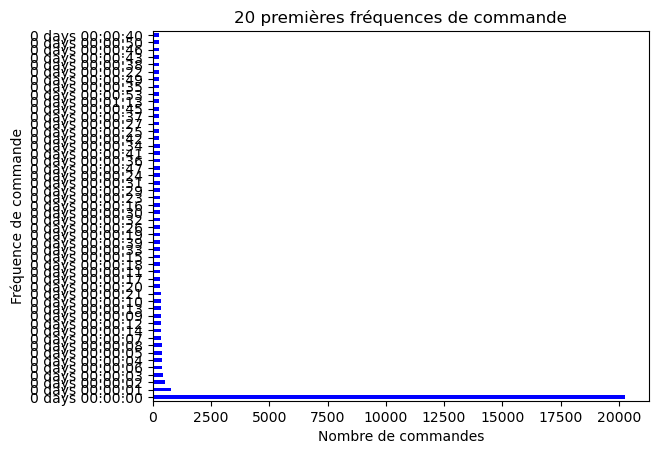

In [119]:
freq_counts = df_orders_freq['order_freq'].value_counts()

# Prendre les 20 premières fréquences de commande dans l'ordre décroissant
top_20_freq = freq_counts.nlargest(50)

# Tracer un graphique en barres horizontales
top_20_freq.plot(kind='barh', color='blue')
plt.title('20 premières fréquences de commande')
plt.xlabel('Nombre de commandes')
plt.ylabel('Fréquence de commande')
plt.show()

# Les payments

In [120]:
 df['payment_type'].value_counts()

credit_card    87776
boleto         23190
voucher         6465
debit_card      1706
not_defined        3
Name: payment_type, dtype: int64

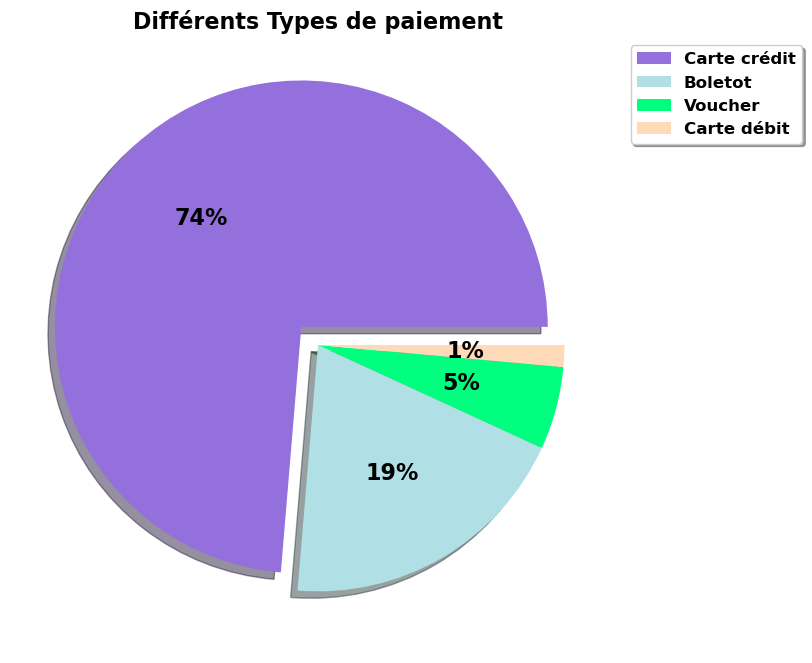

In [121]:
fig, ax = plt.subplots(figsize=(9, 8), subplot_kw=dict(aspect='equal'))
explode = (0.1, 0, 0, 0)
colors = ['MediumPurple', 'PowderBlue', 'SpringGreen', 'PeachPuff']
legend = ['Carte crédit', 'Boletot', 'Voucher',
          'Carte débit']

p = df['payment_type'][df['payment_type']
                                != 'not_defined'].value_counts()
p.plot(kind="pie", legend=False, labels=None, startangle=0,
       explode=explode, autopct='%1.0f%%', pctdistance=0.6, shadow=True,
       textprops={'weight': 'bold', 'fontsize': 16}, colors=colors,
       ax=ax)
ax.legend(legend, loc='best', shadow=True,
          prop={'weight': 'bold', 'size': 12},
          bbox_to_anchor=(0.8, 0, 0.5, 1))
plt.title('Différents Types de paiement', fontweight='bold', size=16)
plt.ylabel("")
plt.show()

In [122]:
df['payment_value'].describe()

count    119140.000000
mean        172.735135
std         267.776077
min           0.000000
25%          60.850000
50%         108.160000
75%         189.240000
max       13664.080000
Name: payment_value, dtype: float64

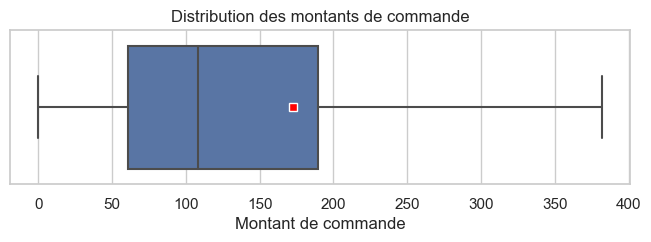

In [123]:
import matplotlib.pyplot as plt
from matplotlib.cbook import boxplot_stats
import seaborn as sns

plt.figure(figsize=(8,2))
sns.set_theme(style="whitegrid")

ax = sns.boxplot(
    x=df['payment_value'],
    showfliers=False,
    showmeans=True,
    meanprops={"marker":"s","markerfacecolor":"red", "markeredgecolor":"white"}
)
plt.title("Distribution des montants de commande")
plt.xlabel("Montant de commande")
plt.show()



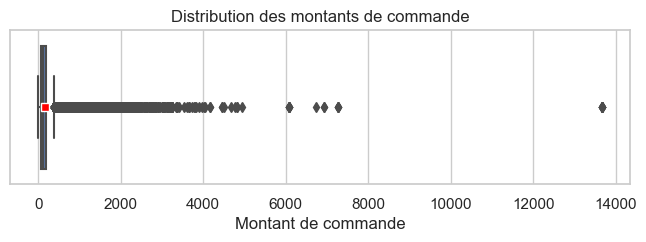

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 2))
sns.set_theme(style="whitegrid")

# Utilisation de sns.boxplot pour tracer la boîte à moustaches
ax = sns.boxplot(
    x=df['payment_value'],
    showfliers=True,  # Afficher les outliers
    showmeans=True,
    meanprops={"marker": "s", "markerfacecolor": "red", "markeredgecolor": "white"}
)

plt.title("Distribution des montants de commande")
plt.xlabel("Montant de commande")
plt.show()

In [125]:
# supprimer les outliers???????????????

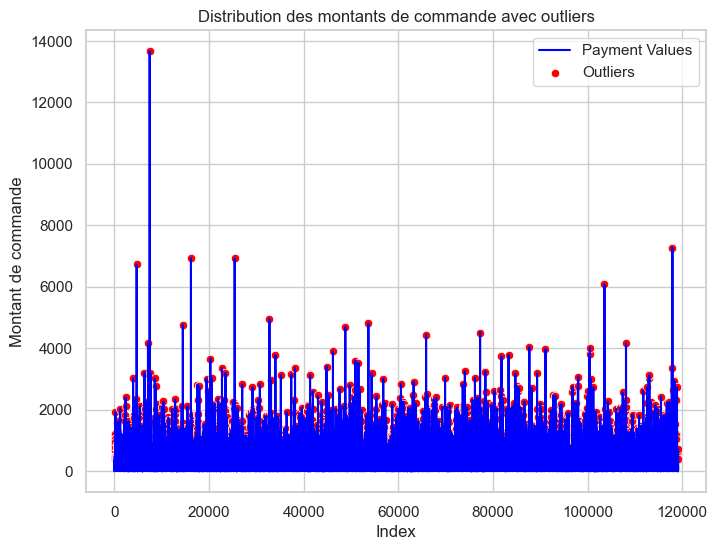

In [126]:
# Vos données
payment_values = df['payment_value']

# Calcul des quartiles
Q1 = payment_values.quantile(0.25)
Q3 = payment_values.quantile(0.75)

# Calcul de l'écart interquartile (IQR)
IQR = Q3 - Q1

# Définition des bornes pour détecter les outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Sélection des outliers
outliers = payment_values[(payment_values < lower_bound) | (payment_values > upper_bound)]

# Affichage des données avec outliers
plt.figure(figsize=(8, 6))

# Courbe pour les données
sns.lineplot(x=range(len(payment_values)), y=payment_values, color='blue', label='Payment Values')

# Marquage des outliers
sns.scatterplot(x=outliers.index, y=outliers, color='red', label='Outliers')

plt.title('Distribution des montants de commande avec outliers')
plt.xlabel('Index')
plt.ylabel('Montant de commande')
plt.legend()
plt.show()

In [127]:
# il y'a des commanades à montant=0

df_montant_zero=df[df['payment_value']==0]

In [128]:
df_montant_zero

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,...,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,product_category_name_english,days_since_last_order
4506,a73c1f73f5772cf801434bf984b0b1a7,968fac81e2c44fb6c1e3ac2a45e6a102,4685,sao paulo,SP,4637ca194b6387e2d538dc89b124b0ee,canceled,2018-09-03 14:14:25,1970-01-01 00:00:00,1970-01-01 00:00:00,...,NaN,NaN,NaN,NaN,1.0,not_defined,1.0,0.0,NaN,44.0
19607,8eab8f9b3c744b76b65f7a2c0c8f2d6c,e4000306cf2f63714e6bb70dd20a6592,74595,goiania,GO,45ed6e85398a87c253db47c2d9f48216,delivered,2017-06-08 21:18:45,2017-06-08 21:30:18,2017-06-09 08:35:18,...,cc419e0650a3c5ba77189a1882b7556a,2017-06-15 21:30:18,56.99,14.15,3.0,voucher,1.0,0.0,fashion,495.0
30763,9af2372a1e49340278e7c1ef8d749f34,8af7ac63b2efbcbd88e5b11505e8098a,78065,cuiaba,MT,fa65dad1b0e818e3ccc5cb0e39231352,shipped,2017-04-20 12:45:34,2017-04-22 09:10:13,2017-04-24 11:31:17,...,06532f10282704ef4c69168b914b77be,2017-04-27 09:10:13,392.55,65.44,14.0,voucher,1.0,0.0,construction,545.0
30772,9af2372a1e49340278e7c1ef8d749f34,8af7ac63b2efbcbd88e5b11505e8098a,78065,cuiaba,MT,fa65dad1b0e818e3ccc5cb0e39231352,shipped,2017-04-20 12:45:34,2017-04-22 09:10:13,2017-04-24 11:31:17,...,06532f10282704ef4c69168b914b77be,2017-04-27 09:10:13,392.55,65.44,13.0,voucher,1.0,0.0,construction,545.0
58409,3532ba38a3fd242259a514ac2b6ae6b6,4fa4365000c7090fcb8cad5713c6d3db,1151,sao paulo,SP,00b1cb0320190ca0daa2c88b35206009,canceled,2018-08-28 15:26:39,1970-01-01 00:00:00,1970-01-01 00:00:00,...,NaN,NaN,NaN,NaN,1.0,not_defined,1.0,0.0,NaN,50.0
61903,843b211abe7b0264dd4a69eafc5bdf43,677ad9cdca6c47c733f0cc6e23d7bb4c,25625,petropolis,RJ,6ccb433e00daae1283ccc956189c82ae,delivered,2017-10-26 23:51:35,2017-10-27 00:46:58,2017-10-27 19:53:03,...,da20530872245d6cd9d2f5725613c430,2017-11-03 00:46:58,94.00,28.04,4.0,voucher,1.0,0.0,leisure,355.0
62754,f2def7f64f36952f2f5a9791f0285f34,cc5aa1b8337e394da54980226bb0f6d4,21040,rio de janeiro,RJ,8bcbe01d44d147f901cd3192671144db,delivered,2018-01-24 23:24:14,2018-01-24 23:37:20,2018-01-30 22:43:30,...,3d871de0142ce09b7081e2b9d1733cb1,2018-01-30 23:37:20,59.00,15.16,4.0,voucher,1.0,0.0,misc,265.0
75493,197a2a6a77da93f678ea0d379f21da0a,6ba987d564bad1f9da8e14b9d3b71c8f,8042,sao paulo,SP,c8c528189310eaa44a745b8d9d26908b,canceled,2018-08-28 20:05:14,1970-01-01 00:00:00,1970-01-01 00:00:00,...,NaN,NaN,NaN,NaN,1.0,not_defined,1.0,0.0,NaN,49.0
90269,648121b599d98c420ef93f6135f8c80c,9077449283dc1319d5e51fb3159b28e2,29230,anchieta,ES,b23878b3e8eb4d25a158f57d96331b18,delivered,2017-05-27 19:20:24,2017-05-27 19:35:17,2017-05-29 04:49:37,...,e49c26c3edfa46d227d5121a6b6e4d37,2017-06-01 19:35:17,135.30,36.27,4.0,voucher,1.0,0.0,leisure,507.0


In [129]:
list(df_montant_zero.columns)

['customer_id',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'order_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'geolocation_zip_code_prefix',
 'geolocation_lat',
 'geolocation_lng',
 'geolocation_city',
 'review_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'payment_sequential',
 'payment_type',
 'payment_installments',
 'payment_value',
 'product_category_name_english',
 'days_since_last_order']

In [130]:
#supprimer la colonnes ecart_livraison _reel_annoce et date_sincelastorder

In [131]:
df_verif=df_montant_zero[['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp','payment_type',
 
 'payment_value']]

In [132]:
df_verif

,order_id,customer_id,order_status,order_purchase_timestamp,payment_type,payment_value
4506,4637ca194b6387e2d538dc89b124b0ee,a73c1f73f5772cf801434bf984b0b1a7,canceled,2018-09-03 14:14:25,not_defined,0.0
19607,45ed6e85398a87c253db47c2d9f48216,8eab8f9b3c744b76b65f7a2c0c8f2d6c,delivered,2017-06-08 21:18:45,voucher,0.0
30763,fa65dad1b0e818e3ccc5cb0e39231352,9af2372a1e49340278e7c1ef8d749f34,shipped,2017-04-20 12:45:34,voucher,0.0
30772,fa65dad1b0e818e3ccc5cb0e39231352,9af2372a1e49340278e7c1ef8d749f34,shipped,2017-04-20 12:45:34,voucher,0.0
58409,00b1cb0320190ca0daa2c88b35206009,3532ba38a3fd242259a514ac2b6ae6b6,canceled,2018-08-28 15:26:39,not_defined,0.0
61903,6ccb433e00daae1283ccc956189c82ae,843b211abe7b0264dd4a69eafc5bdf43,delivered,2017-10-26 23:51:35,voucher,0.0
62754,8bcbe01d44d147f901cd3192671144db,f2def7f64f36952f2f5a9791f0285f34,delivered,2018-01-24 23:24:14,voucher,0.0
75493,c8c528189310eaa44a745b8d9d26908b,197a2a6a77da93f678ea0d379f21da0a,canceled,2018-08-28 20:05:14,not_defined,0.0
90269,b23878b3e8eb4d25a158f57d96331b18,648121b599d98c420ef93f6135f8c80c,delivered,2017-05-27 19:20:24,voucher,0.0


# réponse commande soit annulée ou payer par un bon

# les delais de livraison

In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 119143 entries, 0 to 119142
Data columns (total 34 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   customer_id                    119143 non-null  object        
 1   customer_unique_id             119143 non-null  object        
 2   customer_zip_code_prefix       119143 non-null  int64         
 3   customer_city                  119143 non-null  object        
 4   customer_state                 119143 non-null  object        
 5   order_id                       119143 non-null  object        
 6   order_status                   119143 non-null  object        
 7   order_purchase_timestamp       119143 non-null  datetime64[ns]
 8   order_approved_at              119143 non-null  datetime64[ns]
 9   order_delivered_carrier_date   119143 non-null  datetime64[ns]
 10  order_delivered_customer_date  119143 non-null  datetime64[ns]
 11  

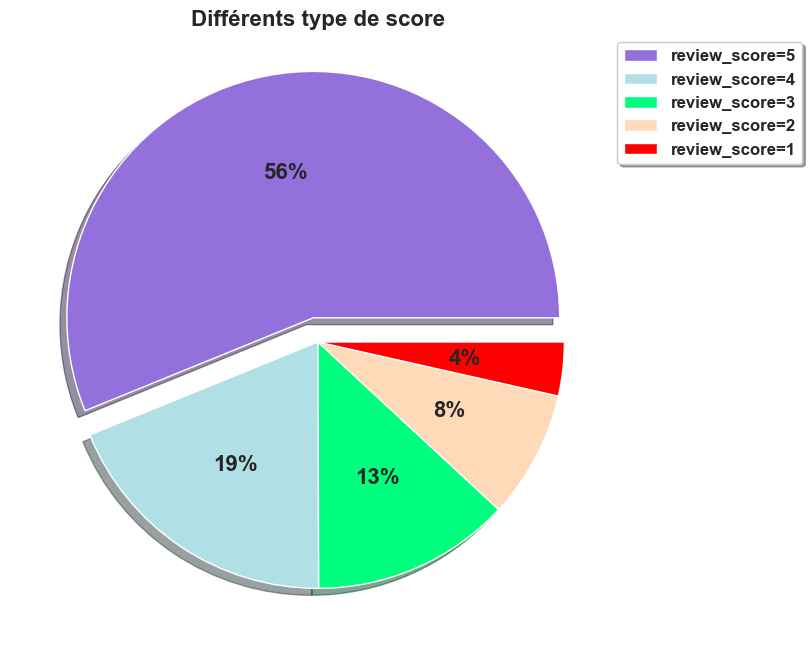

In [134]:
fig, ax = plt.subplots(figsize=(9, 8), subplot_kw=dict(aspect='equal'))
explode = (0.1, 0, 0, 0,0)
colors = ['MediumPurple', 'PowderBlue', 'SpringGreen', 'PeachPuff','red']
legend = ['review_score=5', 'review_score=4', 'review_score=3',
          'review_score=2','review_score=1']

p = df['review_score'][df['review_score']
                                != 'not_defined'].value_counts()
p.plot(kind="pie", legend=False, labels=None, startangle=0,
       explode=explode, autopct='%1.0f%%', pctdistance=0.6, shadow=True,
       textprops={'weight': 'bold', 'fontsize': 16}, colors=colors,
       ax=ax)
ax.legend(legend, loc='best', shadow=True,
          prop={'weight': 'bold', 'size': 12},
          bbox_to_anchor=(0.8, 0, 0.5, 1))
plt.title('Différents type de score', fontweight='bold', size=16)
plt.ylabel("")
plt.show()

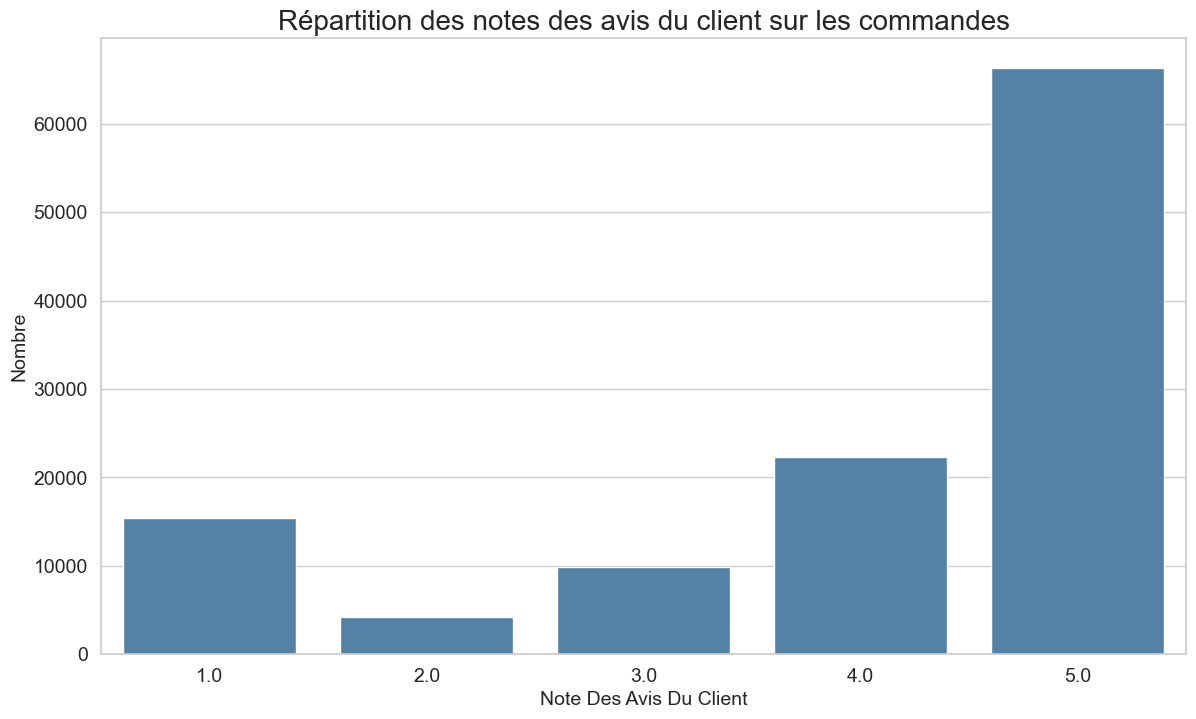

In [135]:


serie_notes_avis = df['review_score'].value_counts(sort=False)

# Countplot
plt.figure(figsize=(14, 8))
sns.barplot(x=serie_notes_avis.index, y=serie_notes_avis.values,
            color='SteelBlue')

plt.title('Répartition des notes des avis du client sur les commandes',
          fontsize=20)
plt.ylabel('Nombre'.title(), fontsize=14)
plt.xlabel('Note des avis du client'.title(), fontsize=14)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [136]:
serie_notes_avis = df['review_score'].value_counts()

In [137]:
serie_notes_avis

5.0    66343
4.0    22319
1.0    15428
3.0     9894
2.0     4162
Name: review_score, dtype: int64

In [138]:
df['review_score'].describe()

count    118146.000000
mean          4.015582
std           1.400436
min           1.000000
25%           4.000000
50%           5.000000
75%           5.000000
max           5.000000
Name: review_score, dtype: float64

In [139]:
df = df.drop(['review_comment_title',
                              'review_comment_message',
                              'review_creation_date',
                              'review_answer_timestamp'],
                             axis=1)

In [140]:
df['order_status'].value_counts()

delivered      115723
shipped          1256
canceled          750
unavailable       652
invoiced          378
processing        376
created             5
approved            3
Name: order_status, dtype: int64

In [141]:
count_customer_orders = df.groupby('customer_unique_id')['customer_id'].count()

In [142]:
count_customer_orders

customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    1
0000b849f77a49e4a4ce2b2a4ca5be3f    1
0000f46a3911fa3c0805444483337064    1
0000f6ccb0745a6a4b88665a16c9f078    1
0004aac84e0df4da2b147fca70cf8255    1
                                   ..
fffcf5a5ff07b0908bd4e2dbc735a684    2
fffea47cd6d3cc0a88bd621562a9d061    1
ffff371b4d645b6ecea244b27531430a    1
ffff5962728ec6157033ef9805bacc48    1
ffffd2657e2aad2907e67c3e9daecbeb    1
Name: customer_id, Length: 96096, dtype: int64

In [143]:
count_customer_orders1= df.groupby('customer_unique_id')['customer_id'].count().reset_index()
count_customer_orders1.columns=['customer_unique_id','counts']


In [144]:
count_customer_orders1.head()

,customer_unique_id,counts
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


In [145]:
count_customer_orders1.describe()

,counts
count,96096.000000
mean,1.239833
std,0.853158
min,1.000000
25%,1.000000
50%,1.000000
75%,1.000000
max,75.000000


In [146]:
count_customer_orders1['counts'].value_counts()

1     81601
2     10554
3      2051
4       977
5       341
6       307
7        74
8        49
10       27
12       26
9        26
11       19
14        8
24        7
15        6
13        5
20        4
21        3
18        2
19        1
22        1
26        1
16        1
38        1
29        1
17        1
75        1
35        1
Name: counts, dtype: int64

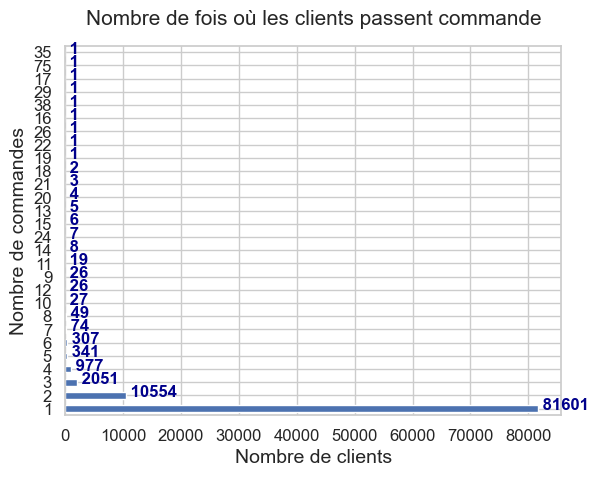

In [147]:
# Nombre des clients ayant commandé plus d'une fois ?


count_customer_orders = df.groupby('customer_unique_id')['customer_id'].count()

count_customer_orders.value_counts().plot(kind='barh', fontsize=12)
plt.title("Nombre de fois où les clients passent commande", fontsize=15, pad=15)
plt.xlabel("Nombre de clients", fontsize=14)
plt.ylabel("Nombre de commandes", fontsize=14)
for i, v in enumerate(count_customer_orders.value_counts()):
    plt.text(
        v,
        i - 0.1,
        " {} ".format(v),
        color='darkblue',
        fontweight='bold',
        fontsize=12
    )
plt.show()

In [148]:
count_customer_orders = df.groupby('customer_unique_id')['order_id'].count()

In [149]:
count_customer_orders.value_counts()

1     81601
2     10554
3      2051
4       977
5       341
6       307
7        74
8        49
10       27
12       26
9        26
11       19
14        8
24        7
15        6
13        5
20        4
21        3
18        2
19        1
22        1
26        1
16        1
38        1
29        1
17        1
75        1
35        1
Name: order_id, dtype: int64

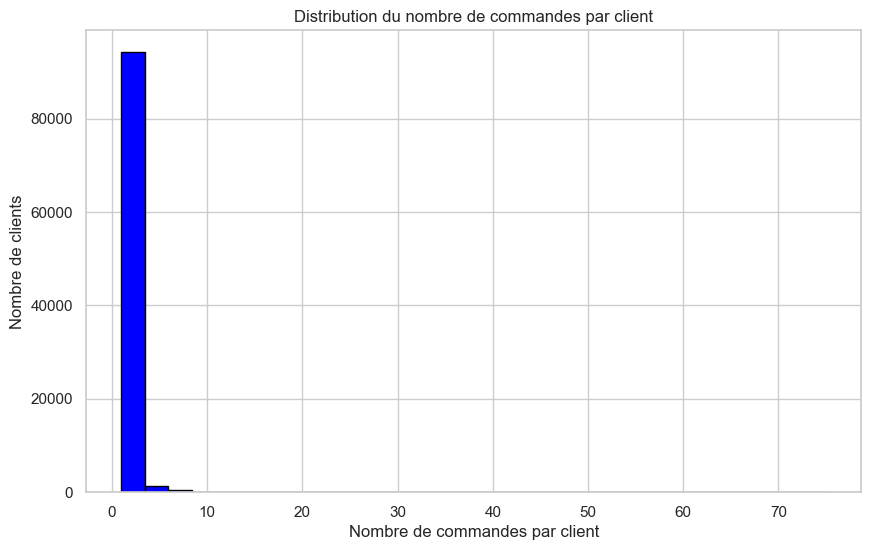

In [151]:
plt.figure(figsize=(10, 6))
plt.hist(count_customer_orders, bins=30, color='blue', edgecolor='black')
plt.xlabel('Nombre de commandes par client')
plt.ylabel('Nombre de clients')
plt.title('Distribution du nombre de commandes par client')
plt.grid(True)
plt.show()

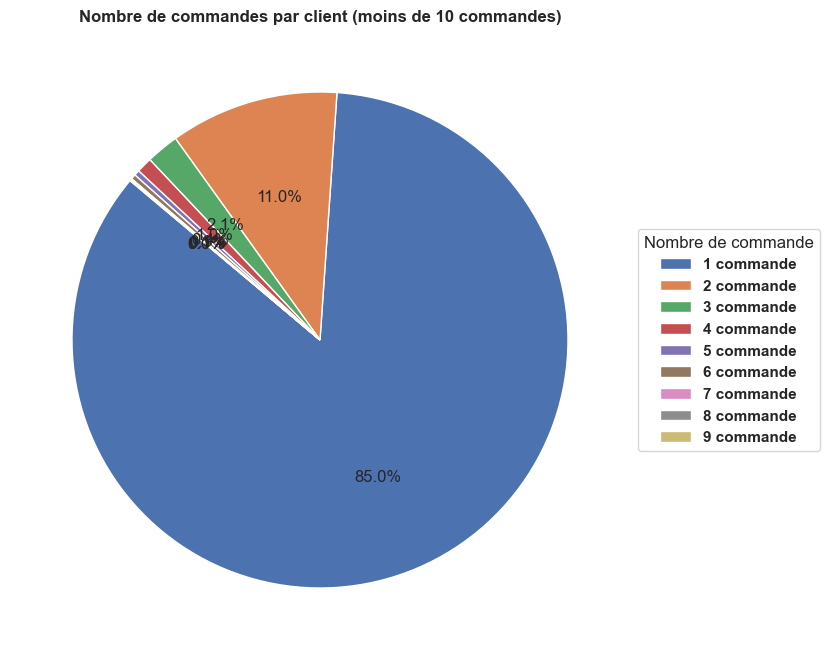

In [152]:
count_customer_orders = df.groupby('customer_unique_id')['order_id'].count()

# Filtrer les clients ayant moins de 10 commandes
count_customer_orders_filtered = count_customer_orders[count_customer_orders < 10]

# Compter le nombre de clients par nombre de commandes
count_filtered_customers = count_customer_orders_filtered.value_counts()
plt.figure(figsize=(8, 20))
plt.pie(count_filtered_customers, autopct='%1.1f%%', startangle=140)
plt.title('Nombre de commandes par client (moins de 10 commandes)', fontweight='bold')
plt.ylabel('')

# Déplacer la légende à droite du graphique
plt.legend(title="Nombre de commande", 
           loc="center left", 
           labels=[f"{count} commande" for count in count_filtered_customers.index], 
           bbox_to_anchor=(1, 0, 0.5, 1),
          prop={'weight':'bold'})

plt.show()

C:\Users\nassc\AppData\Local\Temp\ipykernel_8340\4106904957.py:3: FutureWarning:

The default value of numeric_only in DataFrameGroupBy.sum is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.



Montant minimum dépensé par un client : 0.0
Montant maximum dépensé par un client : 13440.0
Montant moyen dépensé par un client : 148.535835518648
Montant median dépensé par un client : 89.9


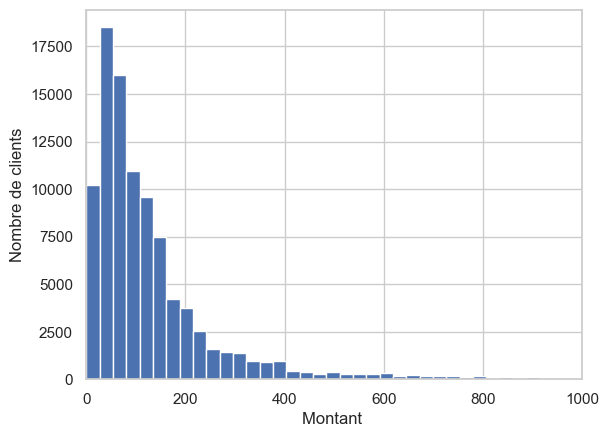

In [153]:
data_tmp = df[["customer_unique_id",'order_id', 'price']]
data_tmp.dropna()
data_tmp3 = data_tmp.groupby(by=["customer_unique_id"]).sum()
print(f"Montant minimum dépensé par un client : {data_tmp3['price'].min()}")
print(f"Montant maximum dépensé par un client : {data_tmp3['price'].max()}")
print(f"Montant moyen dépensé par un client : {data_tmp3['price'].mean()}")
print(f"Montant median dépensé par un client : {data_tmp3['price'].median()}")
data_tmp3['price'].hist(bins=500)

plt.xlim((0,1000))
plt.ylabel('Nombre de clients')
plt.xlabel("Montant ")
plt.show()

In [154]:
data_tmp3.describe()

,price
count,96096.000000
mean,148.535836
std,249.358758
min,0.000000
25%,47.900000
50%,89.900000
75%,159.900000
max,13440.000000


In [155]:
data_tmp3=data_tmp3.reset_index()

In [156]:
data_tmp3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96096 entries, 0 to 96095
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  96096 non-null  object 
 1   price               96096 non-null  float64
dtypes: float64(1), object(1)
memory usage: 1.5+ MB


In [157]:
data_tmp3['price'].value_counts()

59.90      1558
69.90      1450
49.90      1299
89.90      1111
99.90      1100
           ... 
164.56        1
27.61         1
366.50        1
299.70        1
1570.00       1
Name: price, Length: 9070, dtype: int64

In [158]:
data_tmp3['price'].max()

13440.0

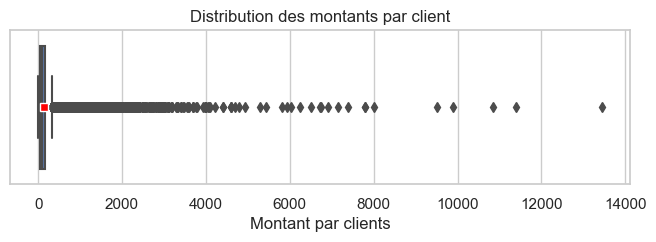

In [159]:
import matplotlib.pyplot as plt
from matplotlib.cbook import boxplot_stats
import seaborn as sns

plt.figure(figsize=(8,2))
sns.set_theme(style="whitegrid")

ax = sns.boxplot(
    x=data_tmp3['price'],
    showfliers=True,
    showmeans=True,
    meanprops={"marker":"s","markerfacecolor":"red", "markeredgecolor":"white"}
)
plt.title("Distribution des montants par client")
plt.xlabel("Montant par clients")
plt.show()



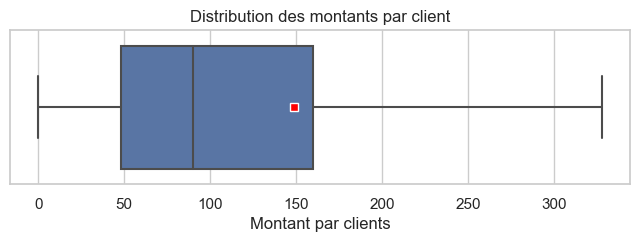

In [160]:
import matplotlib.pyplot as plt
from matplotlib.cbook import boxplot_stats
import seaborn as sns

plt.figure(figsize=(8,2))
sns.set_theme(style="whitegrid")

ax = sns.boxplot(
    x=data_tmp3['price'],
    showfliers=False,
    showmeans=True,
    meanprops={"marker":"s","markerfacecolor":"red", "markeredgecolor":"white"}
)
plt.title("Distribution des montants par client")
plt.xlabel("Montant par clients")
plt.show()


In [161]:
# a refaire en integrant la fonction

Segmentation clients

3.1. Fusion de données

Les variables clés essentielles pour la fusion des jeux de données sont :

customers_id,
order_id,
product_id,
seller_id,
zip_code_prefix,
et product_category_name.

In [162]:
# Suppression variables  inutiles
df = df.drop(['review_id',
                  'seller_id','days_since_last_order'], axis=1)
df.shape

(119143, 27)

In [163]:
def distribution_variables_plages_pourc_donnees(
        dataframe, variable, liste_bins):
    """
    Retourne les plages des pourcentages des valeurs pour le découpage transmis
    Parameters
    ----------
    @param IN : dataframe : DataFrame, obligatoire
                variable : variable à découper obligatoire
                liste_bins: liste des découpages facultatif int ou pintervallindex
    @param OUT : dataframe des plages de nan
    """
    nb_lignes = len(dataframe[variable])
    s_gpe_cut = pd.cut(
        dataframe[variable],
        bins=liste_bins).value_counts().sort_index()
    df_cut = pd.DataFrame({'Plage': s_gpe_cut.index,
                           'nb_données': s_gpe_cut.values})
    df_cut['%_données'] = [
        (row * 100) / nb_lignes for row in df_cut['nb_données']]

    return df_cut.style.hide_index()

In [164]:
def distribution_variables_plages_pourc_nan(dataframe, liste_bins=[]):
    """
    Retourne les plages de valeurs manquantes pour le découpage transmis
    Parameters
    ----------
    @param IN : dataframe : DataFrame, obligatoire
                liste_bins: liste des découpages
                            [0, 25, 50, 75, 90, 100] par défaut
    @param OUT : dataframe des plages de nan
    """
    if len(liste_bins) == 0:
        liste_bins = [0, 25, 50, 75, 90]
    liste_bins.append(100)
    # Nombre de variables par plage de pourcentage de valeurs manquantes
    nb_lignes = dataframe.shape[0]
    s_nan = dataframe.isna().sum()
    df_nan = pd.DataFrame({'Variable': s_nan.index,
                           'nb_nan': s_nan.values})
    df_nan['%_nan'] = [(row * 100) / nb_lignes for row in df_nan['nb_nan']]
    df_nan['%_nan_groupe'] = pd.cut(df_nan['%_nan'], bins=liste_bins)
    s_gpe_nan = df_nan['%_nan_groupe'].value_counts().sort_index()
    df_gp_nan = pd.DataFrame({'Plage de %': s_gpe_nan.index,
                              'nb_variable': s_gpe_nan.values})

In [165]:
def get_missing_values(df_work, pourcentage, affiche_heatmap):
    """Indicateurs sur les variables manquantes
       @param in : df_work dataframe obligatoire
                   pourcentage : boolean si True affiche le nombre heatmap
                   affiche_heatmap : boolean si True affiche la heatmap
       @param out : none
    """

    # 1. Nombre de valeurs manquantes totales
    nb_nan_tot = df_work.isna().sum().sum()
    nb_donnees_tot = np.product(df_work.shape)
    pourc_nan_tot = round((nb_nan_tot / nb_donnees_tot) * 100, 2)
    print(
        f'Valeurs manquantes :{nb_nan_tot} NaN pour {nb_donnees_tot} données ({pourc_nan_tot} %)')

    if pourcentage:
        print("-------------------------------------------------------------")
        print("Nombre et pourcentage de valeurs manquantes par variable\n")
        # 2. Visualisation du nombre et du pourcentage de valeurs manquantes
        # par variable
        values = df_work.isnull().sum()
        percentage = 100 * values / len(df_work)
        table = pd.concat([values, percentage.round(2)], axis=1)
        table.columns = [
            'Nombres de valeurs manquantes',
            '% de valeurs manquantes']
        display(table[table['Nombres de valeurs manquantes'] != 0]
                .sort_values('% de valeurs manquantes', ascending=False)
                .style.background_gradient('seismic'))

    if affiche_heatmap:
        print("-------------------------------------------------------------")
        print("Heatmap de visualisation des valeurs manquantes")
        # 3. Heatmap de visualisation des valeurs manquantes
        plt.figure(figsize=(20, 10))
        sns.heatmap(df_work.isna(), cbar=False)
        plt.show()


Valeurs manquantes :9014 NaN pour 3216861 données (0.28 %)
-------------------------------------------------------------
Nombre et pourcentage de valeurs manquantes par variable



,Nombres de valeurs manquantes,% de valeurs manquantes
product_category_name_english,2552,2.140000
review_score,997,0.840000
order_item_id,833,0.700000
product_id,833,0.700000
shipping_limit_date,833,0.700000
price,833,0.700000
freight_value,833,0.700000
geolocation_zip_code_prefix,322,0.270000
geolocation_lat,322,0.270000
geolocation_lng,322,0.270000


-------------------------------------------------------------
Heatmap de visualisation des valeurs manquantes


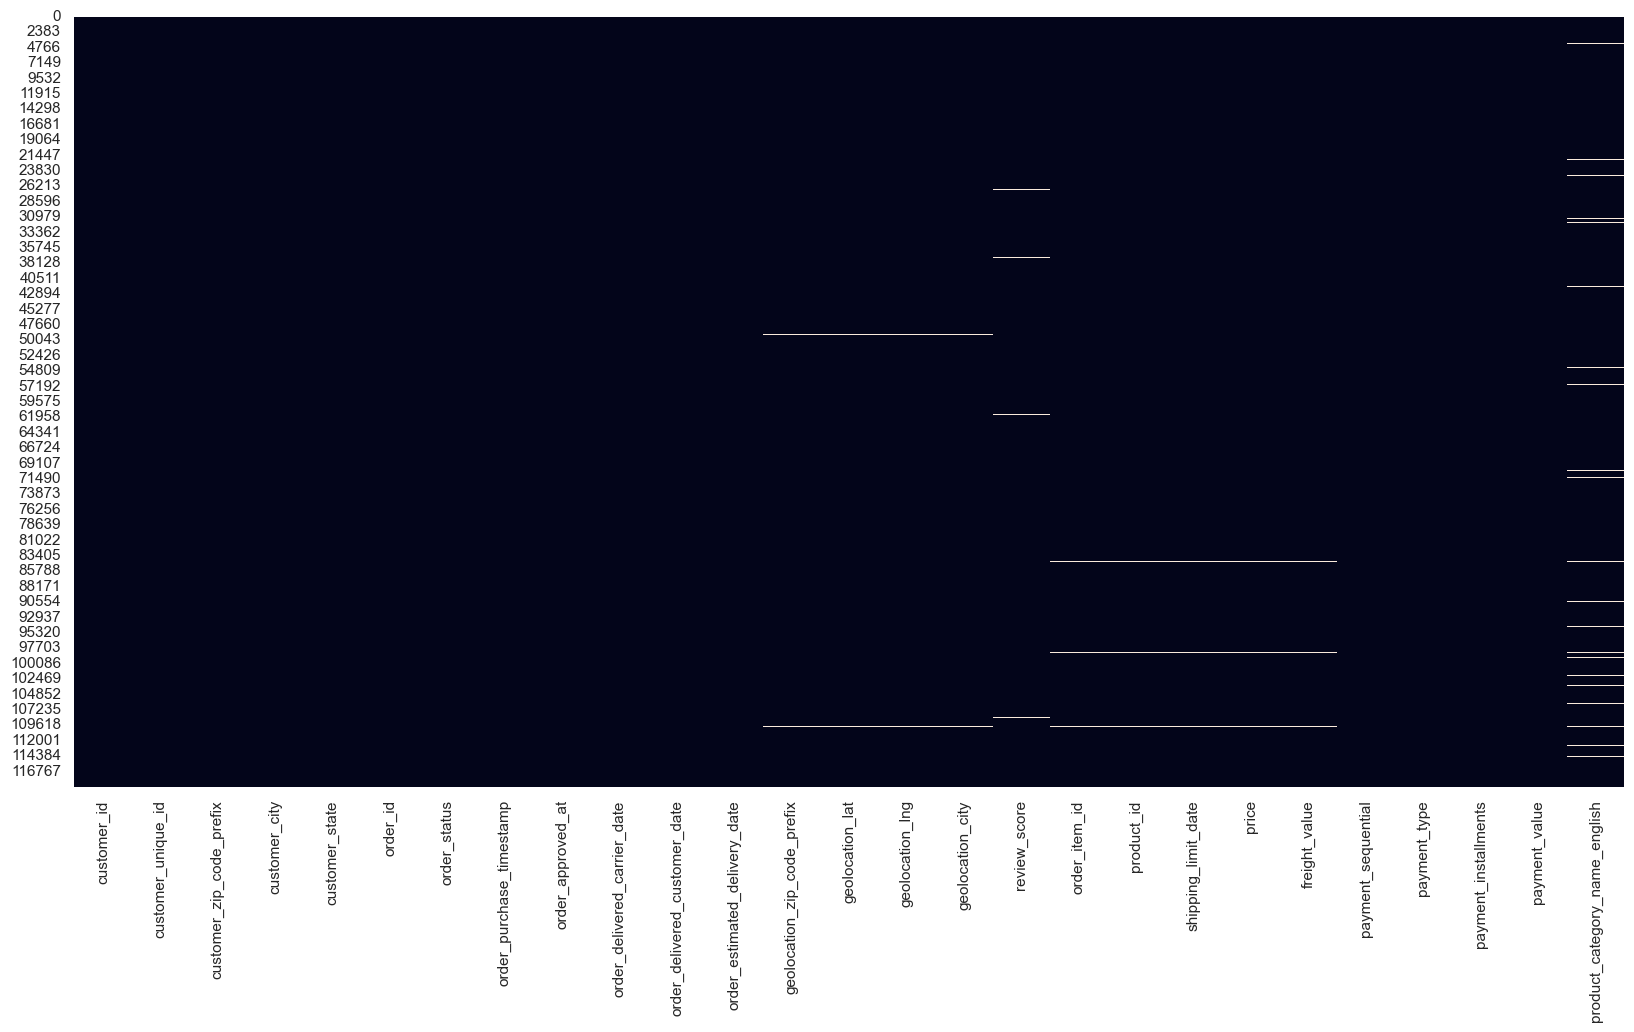

In [166]:
# Valeurs manquantes
get_missing_values(df, True, True)

In [167]:
df = df.dropna()
df.shape

(115314, 27)

In [168]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 115314 entries, 0 to 119142
Data columns (total 27 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   customer_id                    115314 non-null  object        
 1   customer_unique_id             115314 non-null  object        
 2   customer_zip_code_prefix       115314 non-null  int64         
 3   customer_city                  115314 non-null  object        
 4   customer_state                 115314 non-null  object        
 5   order_id                       115314 non-null  object        
 6   order_status                   115314 non-null  object        
 7   order_purchase_timestamp       115314 non-null  datetime64[ns]
 8   order_approved_at              115314 non-null  datetime64[ns]
 9   order_delivered_carrier_date   115314 non-null  datetime64[ns]
 10  order_delivered_customer_date  115314 non-null  datetime64[ns]
 11  

In [169]:
# on ne garde que les commandes livrées:
df = df[df['order_status'] == 'delivered']
df.shape

(112927, 27)

In [170]:
#supprimer la colonne status
df=df.drop('order_status',axis=1)

#Vérification des dates

In [171]:
# Date de commande > date à laquelle la commande a été traitée par les
# logisticiens
df[(df['order_purchase_timestamp'].dt.date >
      df['order_delivered_carrier_date'].dt.date)]

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,...,order_item_id,product_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,product_category_name_english
38019,34ef6181341eb36c47fd601c46878f00,faed38109bbf7da6f035630d92a49a27,4041,sao paulo,SP,7c48bb55e8e4f7e56d412e9653db37bc,2018-07-16 18:40:53,2018-07-16 18:50:22,2018-01-26 13:35:00,2018-07-23 20:04:45,...,1.0,9070fbe936bd54b8a72e0ffe4a6a2564,2018-07-20 18:50:22,40.0,14.58,1.0,credit_card,1.0,54.58,leisure
60683,ac27243bffbc9c58eb62adfb58c71488,216dc3bc64c10494ca97500c2a6b658f,13337,indaiatuba,SP,4021cd7611d6d9ce5ffcd24817fc374f,2018-08-18 11:49:40,2018-08-18 12:10:30,2018-08-14 06:22:00,2018-08-29 04:41:53,...,1.0,98e55bdc6487be7b8c32b0eb689dcb8a,2018-08-23 12:10:30,135.0,8.21,1.0,credit_card,10.0,143.21,home
104302,afeb16c7f46396c0ed54acb45ccaaa40,a2ac81ecc3704410ae240e74d4f0af40,13334,indaiatuba,SP,2aa91108853cecb43c84a5dc5b277475,2017-09-29 08:52:58,2017-09-29 09:07:16,1970-01-01 00:00:00,2017-11-20 19:44:47,...,1.0,44c2baf621113fa7ac95fa06b4afbc68,2017-10-18 10:07:16,179.0,14.98,1.0,credit_card,1.0,193.98,home
117018,e08caf668d499a6d643dafd7c5cc498a,d77cf4be2654aa70ef150f8bfec076a6,91330,porto alegre,RS,2d858f451373b04fb5c984a1cc2defaf,2017-05-25 23:22:43,2017-05-25 23:30:16,1970-01-01 00:00:00,1970-01-01 00:00:00,...,1.0,30b5b5635a79548a48d04162d971848f,2017-06-04 23:30:16,179.0,15.00,1.0,credit_card,4.0,194.00,leisure


In [172]:
# Correction
df = df[~(df['order_purchase_timestamp'].dt.date >
              df['order_delivered_carrier_date'].dt.date)]
df.shape

(112923, 26)

In [173]:
# Date de commande > date à de paiement
df[(df['order_purchase_timestamp'].dt.date > df['order_approved_at']
      .dt.date)]

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,...,order_item_id,product_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,product_category_name_english
10784,0bf35cac6cc7327065da879e2d90fae8,c4c0011e639bdbcf26059ddc38bd3c18,13225,varzea paulista,SP,d77031d6a3c8a52f019764e68f211c69,2017-02-18 11:04:19,1970-01-01,2017-02-23 07:23:36,2017-03-02 16:15:23,...,1.0,02a79d79e818ad0be36cfc843a6af7ad,2017-02-25 10:04:19,28.99,10.96,1.0,boleto,1.0,39.95,leisure
16669,1e101e0daffaddce8159d25a8e53f2b2,c8822fce1d0bfa7ddf0da24fff947172,27945,macae,RJ,12a95a3c06dbaec84bcfb0e2da5d228a,2017-02-17 13:05:55,1970-01-01,2017-02-22 11:23:11,2017-03-02 11:09:19,...,1.0,c6dd917a0be2a704582055949915ab32,2017-02-21 12:05:55,79.99,15.77,1.0,boleto,1.0,95.76,home
25052,d5de688c321096d15508faae67a27051,d49f3dae6bad25d05160fc17aca5942d,36400,conselheiro lafaiete,MG,7002a78c79c519ac54022d4f8a65e6e8,2017-01-19 22:26:59,1970-01-01,2017-01-27 11:08:05,2017-02-06 14:22:19,...,1.0,c3b271f47e73d0c9ccf1b43b7606c705,2017-01-29 22:26:59,45.90,14.52,1.0,boleto,1.0,60.42,home
27263,07a2a7e0f63fd8cb757ed77d4245623c,79af1bbf230a2630487975aa5d7d6220,37660,paraisopolis,MG,51eb2eebd5d76a24625b31c33dd41449,2017-02-18 15:52:27,1970-01-01,2017-02-23 03:09:14,2017-03-07 13:57:47,...,1.0,7868a64aa111bbb4f41f8e1146c0becb,2017-02-28 14:52:27,59.90,17.16,1.0,boleto,1.0,77.06,home
32922,68d081753ad4fe22fc4d410a9eb1ca01,2e0a2166aa23da2472c6a60c4af6f7a6,3573,sao paulo,SP,d69e5d356402adc8cf17e08b5033acfb,2017-02-19 01:28:47,1970-01-01,2017-02-23 03:11:48,2017-03-02 03:41:58,...,1.0,cae2e38942c8489d9d7a87a3f525c06b,2017-02-26 01:28:47,149.80,13.63,1.0,boleto,1.0,163.43,home
47127,d85919cb3c0529589c6fa617f5f43281,c094ac95fcd52f821809ec232a7a6956,95795,sao vendelino,RS,3c0b8706b065f9919d0505d3b3343881,2017-02-17 15:53:27,1970-01-01,2017-02-22 11:31:30,2017-03-03 11:47:47,...,1.0,db8ed3d08891d16a2438a67ab3acb740,2017-02-22 14:53:27,133.99,23.20,1.0,boleto,1.0,157.19,home
49782,74bebaf46603f9340e3b50c6b086f992,f79be7c08dd24b72d34634f1b89333a4,65110,sao jose de ribamar,MA,2babbb4b15e6d2dfe95e2de765c97bce,2017-02-18 17:15:03,1970-01-01,2017-02-22 11:23:11,2017-03-03 18:43:43,...,1.0,c6dd917a0be2a704582055949915ab32,2017-02-22 16:15:03,79.99,26.82,1.0,boleto,1.0,106.81,home
52794,684cb238dc5b5d6366244e0e0776b450,6ff8b0d7b35d5c945633b8d60165691b,11030,santos,SP,c1d4211b3dae76144deccd6c74144a88,2017-01-19 12:48:08,1970-01-01,2017-01-25 14:56:50,2017-01-30 18:16:01,...,1.0,5ab02ca028398131a5ae91401eb49788,2017-01-23 12:48:08,39.99,14.52,1.0,boleto,1.0,54.51,leisure
63368,a3d3c38e58b9d2dfb9207cab690b6310,5a4fa4919cbf2b049e72be460a380e5b,35620,abaete,MG,2eecb0d85f281280f79fa00f9cec1a95,2017-02-17 17:21:55,1970-01-01,2017-02-22 11:42:51,2017-03-03 12:16:03,...,1.0,4fd676d9c4723d475026e40aeae56957,2017-02-21 16:21:55,135.00,19.23,1.0,boleto,1.0,154.23,construction
71934,2127dc6603ac33544953ef05ec155771,8a9a08c7ca8900a200d83cf838a07e0b,6708,cotia,SP,e04abd8149ef81b95221e88f6ed9ab6a,2017-02-18 14:40:00,1970-01-01,2017-02-23 12:04:47,2017-03-01 13:25:33,...,1.0,0e20a07ca1714df21f9b07ca3bf7c682,2017-02-22 13:40:00,309.90,39.11,1.0,boleto,1.0,349.01,high_technology


In [174]:
# Correction
df = df[~(df['order_purchase_timestamp'].dt.date >
              df['order_approved_at'].dt.date)]
df.shape

(112909, 26)

In [175]:
# Date de commande > date de livraison
df[(df['order_purchase_timestamp'].dt.date >
      df['order_delivered_customer_date'].dt.date)]

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_id,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,...,order_item_id,product_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value,product_category_name_english
10870,5e89028e024b381dc84a13a3570decb4,2f17c5b324ad603491521b279a9ff4de,18255,quadra,SP,f5dd62b788049ad9fc0526e3ad11a097,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,1970-01-01,...,1.0,2167c8f6252667c0eb9edd51520706a1,2018-06-26 07:19:05,329.00,25.24,1.0,debit_card,1.0,354.24,misc
14421,28c37425f1127d887d7337f284080a0f,175378436e2978be55b8f4316bce4811,9431,ribeirao pires,SP,20edc82cf5400ce95e1afacc25798b31,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,1970-01-01,...,1.0,55bfa0307d7a46bed72c492259921231,2018-07-03 16:29:30,45.90,9.07,1.0,credit_card,1.0,54.97,leisure
16044,29f0540231702fda0cfdee0a310f11aa,1bd06a0c0df8b23dacfd3725d2dc0bb9,12445,pindamonhangaba,SP,2ebdfc4f15f23b91474edf87475f108e,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,1970-01-01,...,1.0,e7d5464b94c9a5963f7c686fc80145ad,2018-07-05 17:15:12,139.00,19.07,1.0,credit_card,3.0,158.07,misc
61956,ec05a6d8558c6455f0cbbd8a420ad34f,13467e882eb3a701826435ee4424f2bd,18520,cerquilho,SP,2d1e2d5bf4dc7227b3bfebb81328c15f,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,1970-01-01,...,1.0,a50acd33ba7a8da8e9db65094fa990a4,2017-12-04 17:56:40,117.30,17.53,1.0,credit_card,3.0,134.83,misc
102388,dd1b84a7286eb4524d52af4256c0ba24,cce5e8188bf42ffb3bb5b18ff58f5965,7261,guarulhos,SP,ab7c89dc1bf4a1ead9d6ec1ec8968a84,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,1970-01-01,...,1.0,a2a7efc985315e86d4f0f705701b342b,2018-06-18 12:30:35,110.99,9.13,1.0,credit_card,5.0,120.12,high_technology
104571,cfda40ca8dd0a5d486a9635b611b398a,3bc508d482a402715be4d5cf4020cc81,13170,sumare,SP,e69f75a717d64fc5ecdfae42b2e8e086,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,1970-01-01,...,1.0,e7d5464b94c9a5963f7c686fc80145ad,2018-07-05 22:15:14,139.00,19.07,1.0,credit_card,1.0,158.07,misc
106953,4f1d63d35fb7c8999853b2699f5c7649,ebf7e0d43a78c81991a4c59c145c75db,13560,sao carlos,SP,0d3268bad9b086af767785e3f0fc0133,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,1970-01-01,...,1.0,ec165cd31c50585786ffda6feff5d0a6,2018-07-05 21:29:54,188.99,15.63,1.0,credit_card,4.0,204.62,leisure


In [176]:
# Correction
df = df[~(df['order_purchase_timestamp'].dt.date >
              df['order_delivered_customer_date'].dt.date)]
df.shape

(112902, 26)

Indicateur RFM - Récence

La récence est la durée entre une date de référence et la dernière date d'achat de chaque client.

Date de référence ?

Habituellement, en marketing, la date de référence est la date de dernière transaction plus 1 jour.

In [177]:
# Période de commande (dernier achat)?
min = df['order_purchase_timestamp'].min().strftime('%d/%m/%Y %Hh%m')
max = df['order_purchase_timestamp'].max().strftime('%d/%m/%Y %Hh%m')
print(f'Période d\'achat : du {min} au {max}')

Période d'achat : du 03/10/2016 09h10 au 29/08/2018 15h08


In [178]:
import datetime
date_ref = df['order_purchase_timestamp'].max() + \
    datetime.timedelta(days=1)
s_dateref = date_ref.strftime('%d/%m/%Y %Hh%m')
print(f'Data de référence pour la récence : {s_dateref}')

Data de référence pour la récence : 30/08/2018 15h08


Date de dernier achat ?

La date de dernier achat du client est calculé par : df['order_purchase_timestamp'].max()

In [179]:
# Alimentation du dictionnaire d'aggrégation pour une ligne de client
# unique
# Ajout de la récence en nombre de jours
dico_aggr_rfm = {'order_purchase_timestamp': lambda x: (
    date_ref - x.max()).days}
dico_rename_rfm = {'order_purchase_timestamp': 'rfm_recence'}

Indicateur RFM - Fréquence

La fréquence est 'le nombre de fois où votre client a fait une transaction pendant une période donnée' donc le nombre de commande sur la période de l'étude : data['order_id'].count()

In [180]:
# Alimentation du dictionnaire d'aggrégation pour une ligne de client
# unique
# Ajout de la fréquence en nombre d'achat sur la période
dico_aggr_rfm['order_id'] = 'count'
dico_rename_rfm['order_id'] = 'rfm_frequence'

Indicateur RFM - Montant

Le montant correspond à la somme ou moyenne des dépenses de votre client : df['payment_value'].sum()

In [181]:

# Alimentation du dictionnaire d'aggrégation pour une ligne de client
# unique
# Ajout de la fréquence en nombre d'achat sur la période
dico_aggr_rfm['price'] = 'sum'
dico_rename_rfm['price'] = 'rfm_montant'

In [182]:
# Ajout de la score review sur la période
dico_aggr_rfm['review_score'] = 'sum'
dico_rename_rfm['review_score'] = 'rfm_review'

In [183]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 112902 entries, 0 to 119142
Data columns (total 26 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   customer_id                    112902 non-null  object        
 1   customer_unique_id             112902 non-null  object        
 2   customer_zip_code_prefix       112902 non-null  int64         
 3   customer_city                  112902 non-null  object        
 4   customer_state                 112902 non-null  object        
 5   order_id                       112902 non-null  object        
 6   order_purchase_timestamp       112902 non-null  datetime64[ns]
 7   order_approved_at              112902 non-null  datetime64[ns]
 8   order_delivered_carrier_date   112902 non-null  datetime64[ns]
 9   order_delivered_customer_date  112902 non-null  datetime64[ns]
 10  order_estimated_delivery_date  112902 non-null  datetime64[ns]
 11  

Dataframe de travail RFM

In [184]:
# Constitution du dataframe de travail RFM
df_rfm = df.groupby('customer_unique_id').agg(dico_aggr_rfm)
df_rfm.rename(columns=dico_rename_rfm, inplace=True)


In [185]:
df_rfm=df_rfm.reset_index()

In [186]:
df_rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91223 entries, 0 to 91222
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  91223 non-null  object 
 1   rfm_recence         91223 non-null  int64  
 2   rfm_frequence       91223 non-null  int64  
 3   rfm_montant         91223 non-null  float64
 4   rfm_review          91223 non-null  float64
dtypes: float64(2), int64(2), object(1)
memory usage: 3.5+ MB


In [187]:
# Export des données pour analyse RFM
df_rfm.to_csv('OLIST_data_RFM.csv')

# Ajout des  indicateurs RFM au dataframe de travail global : dataframe pour la maintenance



In [193]:
df = pd.merge(df, df_rfm, on='customer_unique_id', how='left')


In [194]:
df.to_csv('OLIST_data_analyse_stabilite.csv')
